In [2]:
# Cell 0
# ─────────────────────────────────────────────────────────────
# 한글 폰트 설정 (Google Colab 환경)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# 윈도우 환경 한글 폰트(맑은 고딕) 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("윈도우 폰트 설정이 완료되었습니다!")

윈도우 폰트 설정이 완료되었습니다!


In [3]:
# Cell 1 데이터 설명
#
# [데이터 출처]
# 대만 증권거래소 상장기업 부도예측 데이터 (UCI Repository)
# https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction
#
# [데이터 특성]
# - 전체: 6819개 기업 (부도 220개, 정상 6599개)
# - 부도율: 3.23%
# - 변수: 재무비율 95개 + 타깃(Bankrupt?) 1개
# - 기간: 1999~2009년 대만 증권거래소 상장기업
# ─────────────────────────────────────────────────────────────

In [4]:
# Cell 2
# ─────────────────────────────────────────────────────────────
# 데이터 로드
# ─────────────────────────────────────────────────────────────
import pandas as pd

file_path = 'C:\ITStudy\seminar_02\data.csv'

try:
    df = pd.read_csv(file_path)
    print("데이터를 성공적으로 로드했습니다:")
    display(df.head())
except FileNotFoundError:
    print(f"오류: '{file_path}' 파일을 찾을 수 없습니다.")
except Exception as e:
    print(f"파일을 로드하는 중 오류가 발생했습니다: {e}")

<>:7: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:7: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\최성민\AppData\Local\Temp\ipykernel_26124\3524530265.py:7: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  file_path = 'C:\ITStudy\seminar_02\data.csv'


데이터를 성공적으로 로드했습니다:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


한글 폰트 설정 완료
데이터 크기: (6819, 96)

타깃 변수 분포:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

파산 비율: 3.23%


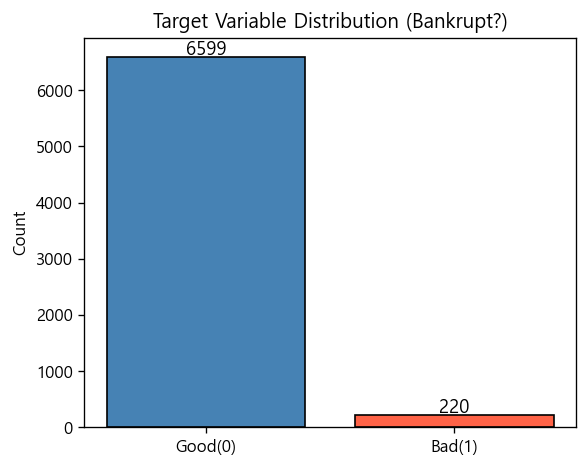

In [6]:
# Cell 3
# ─────────────────────────────────────────────────────────────
# 라이브러리 임포트 및 기본 EDA
#
# [논문 순서 - 김종윤 2019]
# 1단계: 데이터 수집 및 탐색 (논문 p.28)
# "모형 개발을 위해 사용된 데이터는 ... 탐색적 분석을 수행하였다"
# → 타깃 분포, 결측치, 변수 분포 순서로 탐색
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from IPython.display import display

# 윈도우용 맑은 고딕 폰트 적용 (에러 방지용 수정됨)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
print("한글 폰트 설정 완료")

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

print("데이터 크기:", df.shape)
print("\n타깃 변수 분포:")
target_counts = df['Bankrupt?'].value_counts()
print(target_counts)
print(f"\n파산 비율: {target_counts[1] / len(df) * 100:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Good(0)', 'Bad(1)'], target_counts.values,
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Target Variable Distribution (Bankrupt?)')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# Cell 4
# ─────────────────────────────────────────────────────────────
# 세그먼트 분류 검토
#
# [논문 p.28, p.61]
# "신용평가모형은 기업의 규모 및 업종에 의해 평가항목 및 평점이
#  차별화되어 적용된다" (NICE 공시 참고)
# → 외감/비외감, 업종별로 모형을 분리하는 것이 원칙
#
# [본 연구 적용]
# 대만 증권거래소 상장기업은 전원 외부감사 의무 대상
# → 기업 규모 세그먼트: 외감 단일 적용
# → 업종 세그먼트: 재무비율 기반 데이터로 업종 구분 불가
# → 단일 세그먼트 모형으로 진행
# ─────────────────────────────────────────────────────────────
print("세그먼트 검토 완료")
print("→ 대만 상장기업: 전원 외감 대상 → 단일 세그먼트 적용")
print("→ 업종 구분 정보 없음 → 업종별 분리 불가")

세그먼트 검토 완료
→ 대만 상장기업: 전원 외감 대상 → 단일 세그먼트 적용
→ 업종 구분 정보 없음 → 업종별 분리 불가


In [8]:
# Cell 5
# ─────────────────────────────────────────────────────────────
# 결측치 현황 파악
#
# [논문 p.28-29]
# "변수 변환에 앞서 결측치, 이상치 등을 확인하고 처리한다"
# → 결측치 비중 및 패턴 확인 후 처리 방향 결정
# ─────────────────────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"결측치 있는 컬럼 수: {len(missing_df)} / {df.shape[1]}")
print(missing_df.head(20))

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    missing_plot = missing_df[missing_df['Missing %'] > 0]['Missing %']
    ax.barh(missing_plot.index[:20], missing_plot.values[:20], color='tomato')
    ax.set_xlabel('Missing %')
    ax.set_title('Top 20 Columns by Missing Rate')
    plt.tight_layout()
    plt.show()
else:
    print("결측치 없음 - 전처리 불필요")

결측치 있는 컬럼 수: 0 / 96
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
결측치 없음 - 전처리 불필요


수치형 변수 수: 95


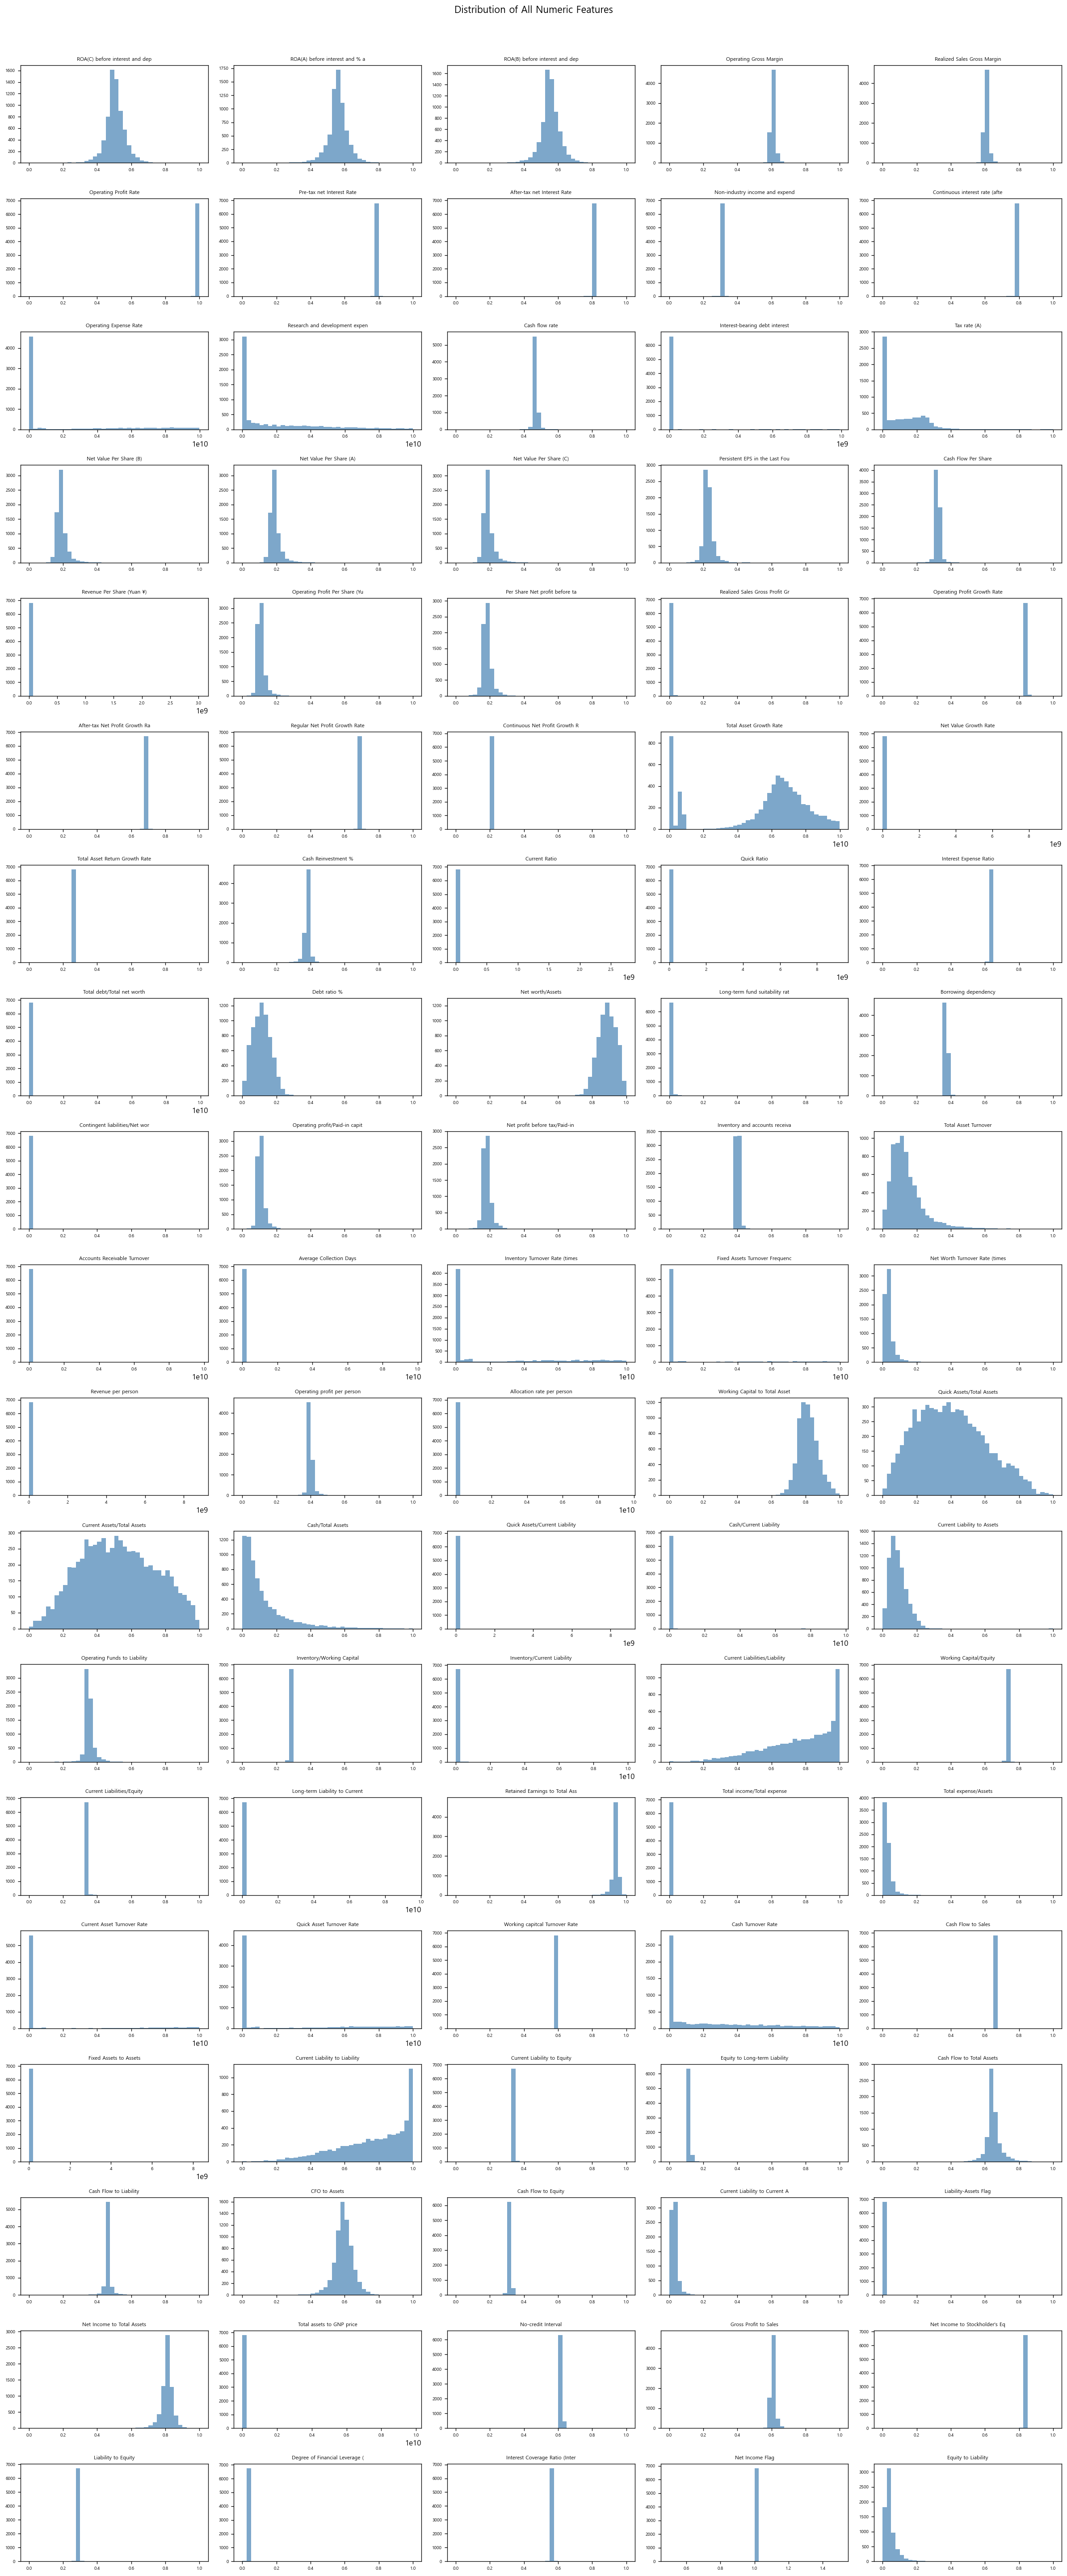

In [9]:
# Cell 6
# ─────────────────────────────────────────────────────────────
# 전체 변수 분포 시각화
#
# [논문 p.28-29]
# "각 설명변수의 분포를 확인하여 이상치 및 특수값 패턴을 탐색한다"
# → 히스토그램으로 분포 형태, 이상값 존재 여부 확인
# → 이후 특수값(≈1e10) 처리 및 Fine Classing 전 사전 탐색 목적
# ─────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'Bankrupt?']
print(f"수치형 변수 수: {len(num_cols)}")

n_cols = 5
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='none', alpha=0.7)
    axes[i].set_title(col[:30], fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Numeric Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

=== 파산/정상 중앙값 차이 상위 20개 변수 ===
Inventory Turnover Rate (times)          7.034483e+10
Long-term Liability to Current Assets    2.440000e+00
Total debt/Total net worth               1.924400e+00
Fixed Assets Turnover Frequency          1.100500e+00
Tax rate (A)                             1.000000e+00
Total assets to GNP price                8.679000e-01
Allocation rate per person               8.503000e-01
Quick Asset Turnover Rate                8.279000e-01
Current Liability to Assets              7.960000e-01
Current Liability to Current Assets      7.571000e-01
Cash/Current Liability                   7.503000e-01
Research and development expense rate    7.155000e-01
Debt ratio %                             7.135000e-01
Cash/Total Assets                        6.942000e-01
Quick Ratio                              6.371000e-01
Interest-bearing debt interest rate      5.741000e-01
Quick Assets/Current Liability           5.678000e-01
Fixed Assets to Assets                   4.903000e-

C:\Users\최성민\AppData\Local\Temp\ipykernel_26124\676640547.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\최성민\AppData\Local\Temp\ipykernel_26124\676640547.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\최성민\AppData\Local\Temp\ipykernel_26124\676640547.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\최성민\AppData\Local\Temp\ipykernel_26124\676640547.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[

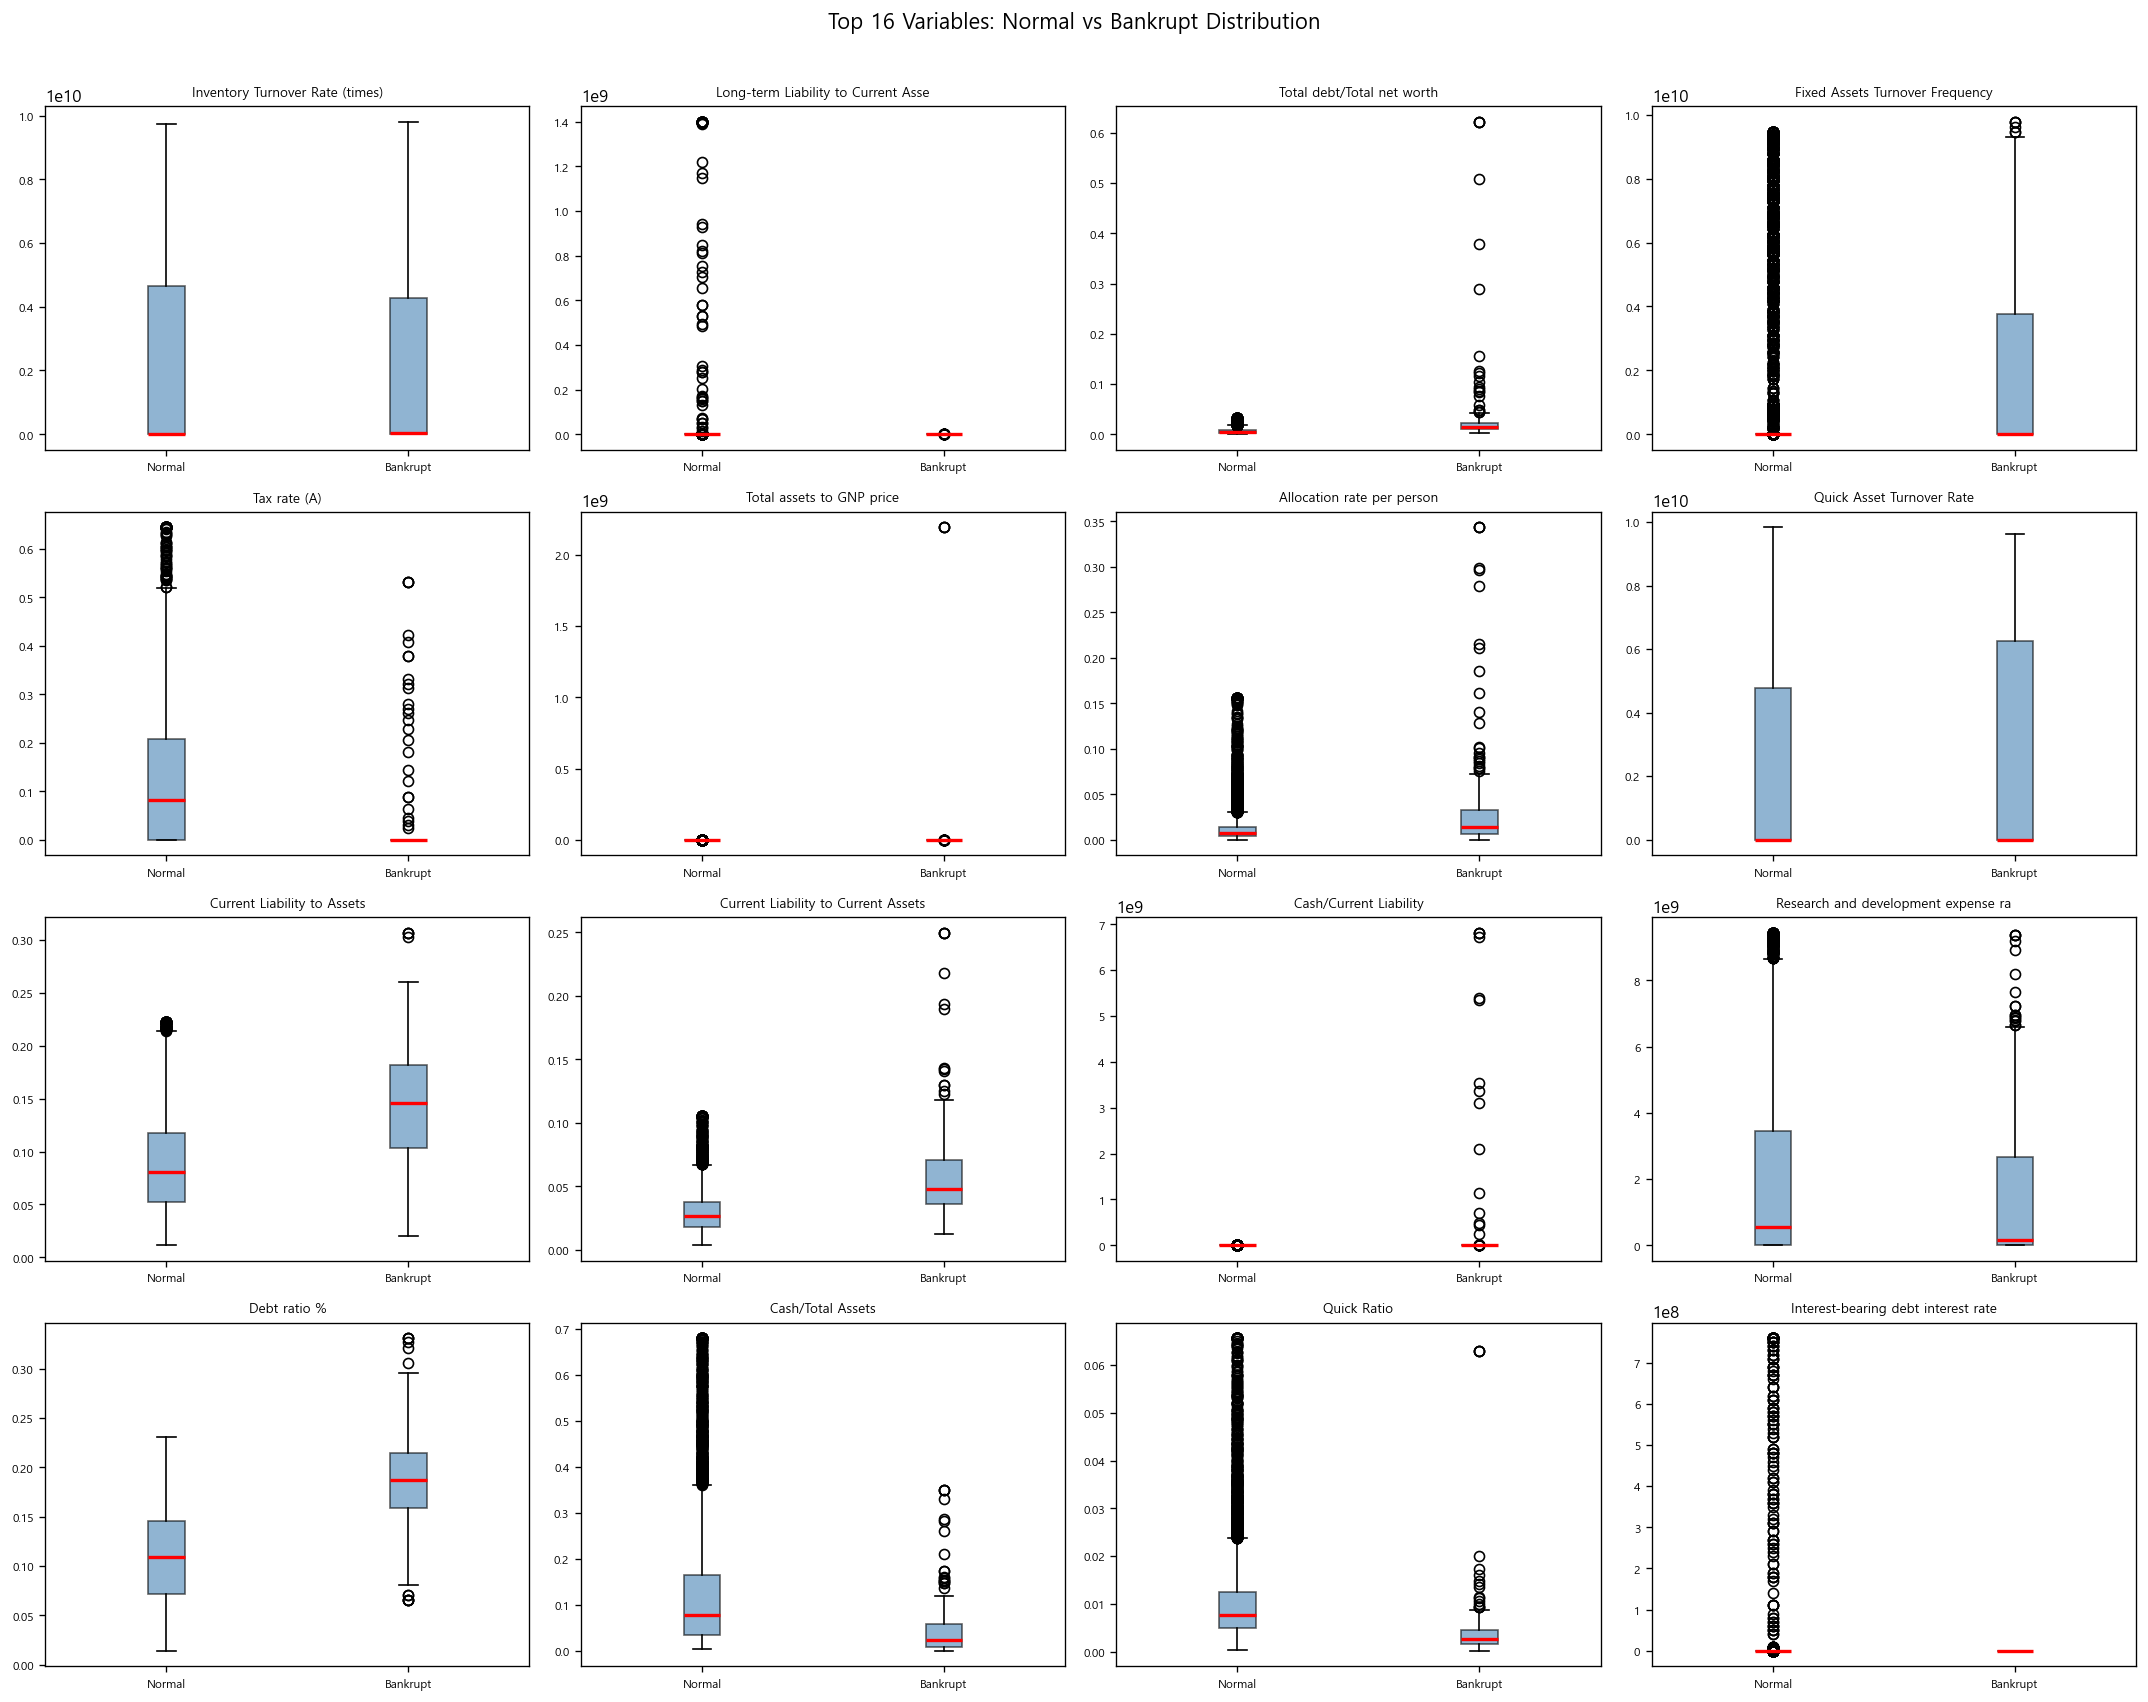

In [10]:
# Cell 7
# ─────────────────────────────────────────────────────────────
# 파산/정상 집단별 변수 분포 비교
#
# [논문 p.28-29]
# "설명변수와 종속변수 간의 관계를 탐색하여
#  변별력 있는 변수를 1차적으로 파악한다"
# → 파산/정상 집단 간 중앙값 차이가 클수록
#   Fine Classing 단계에서 높은 KS를 보일 가능성 높음
# → 박스플롯으로 집단 간 분포 차이 시각적 확인
# ─────────────────────────────────────────────────────────────
bankrupt = df[df['Bankrupt?'] == 1]
normal   = df[df['Bankrupt?'] == 0]

diff_ratio = {}
for col in num_cols:
    med_b = bankrupt[col].median()
    med_n = normal[col].median()
    denom = abs(med_n) if abs(med_n) > 1e-10 else 1e-10
    diff_ratio[col] = abs(med_b - med_n) / denom

diff_series = pd.Series(diff_ratio).sort_values(ascending=False)

print("=== 파산/정상 중앙값 차이 상위 20개 변수 ===")
print(diff_series.head(20).round(4))

top16 = diff_series.head(16).index.tolist()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(top16):
    data_0 = normal[col].clip(
        normal[col].quantile(0.01), normal[col].quantile(0.99))
    data_1 = bankrupt[col].clip(
        bankrupt[col].quantile(0.01), bankrupt[col].quantile(0.99))
    axes[i].boxplot(
        [data_0, data_1], labels=['Normal', 'Bankrupt'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(col[:35], fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Top 16 Variables: Normal vs Bankrupt Distribution',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Cell 8
# ─────────────────────────────────────────────────────────────
# 이중 분포(bimodal) 패턴 변수 식별
#
# [논문 p.29]
# "연속형 변수의 경우 값의 범위와 분포 형태를 확인하여
#  이상치 및 특수값 처리 방향을 결정한다"
# → 동일 변수 내 비율값(0~1)과 절댓값이 혼재하는 경우:
#   Fine Classing 시 구간 왜곡 발생 가능
# → 0~1 사이 비중과 1 초과 비중이 둘 다 10% 이상이면 혼재 의심
# ─────────────────────────────────────────────────────────────
bimodal_candidates = []

for col in num_cols:
    total    = len(df[col])
    ratio_01 = ((df[col] >= 0) & (df[col] <= 1)).sum() / total
    over_1   = (df[col] > 1).sum() / total
    over_100 = (df[col] > 100).sum() / total

    if ratio_01 > 0.1 and over_1 > 0.1:
        bimodal_candidates.append({
            'feature': col,
            '0~1 비중': round(ratio_01, 3),
            '1 초과 비중': round(over_1, 3),
            '100 초과 비중': round(over_100, 3),
            'max': df[col].max()
        })

bimodal_df = pd.DataFrame(bimodal_candidates).sort_values(
    '1 초과 비중', ascending=False)
print(f"혼재 의심 변수 수: {len(bimodal_df)}개\n")
print(bimodal_df.to_string())

혼재 의심 변수 수: 8개

                                 feature  0~1 비중  1 초과 비중  100 초과 비중           max
2                Total Asset Growth Rate   0.118    0.882      0.882  9.990000e+09
7                     Cash Turnover Rate   0.378    0.622      0.622  1.000000e+10
1  Research and development expense rate   0.409    0.591      0.591  9.980000e+09
3        Inventory Turnover Rate (times)   0.568    0.432      0.432  9.990000e+09
6              Quick Asset Turnover Rate   0.651    0.349      0.349  1.000000e+10
0                 Operating Expense Rate   0.665    0.335      0.335  9.990000e+09
5            Current Asset Turnover Rate   0.819    0.181      0.181  1.000000e+10
4        Fixed Assets Turnover Frequency   0.820    0.180      0.180  9.990000e+09


In [16]:
# Cell 9
# ─────────────────────────────────────────────────────────────
# 특수값(≈1e10) 처리
#
# [논문 p.29]
# "결측치 및 이상치는 별도 구간으로 처리하거나 NaN으로 변환한 후
#  Fine Classing 단계에서 별도 bin으로 취급한다"
# → max값이 9e9 이상인 변수: 9,999,999,999 인코딩(결측 대체값)으로 판단
# → NaN으로 변환 후 Fine Classing에서 별도 bin 처리
#
# [예외]
# Fixed Assets Turnover Frequency:
# 특수값 구간 파산율(6.96%) > 정상값 파산율(3.14%)
# → 해당 변수는 특수값 자체가 독립적 정보를 가짐
# → NaN 처리 후 Fine Classing에서 별도 bin WOE로 반영
# ─────────────────────────────────────────────────────────────
special_val_cols   = bimodal_df['feature'].tolist()
SPECIAL_THRESHOLD  = 9e9

df_clean = df.copy()

for col in special_val_cols:
    special_mask        = df_clean[col] > SPECIAL_THRESHOLD
    special_count       = special_mask.sum()
    special_rate        = special_count / len(df_clean) * 100
    bankrupt_rate_sp    = df_clean.loc[special_mask,  'Bankrupt?'].mean() * 100
    bankrupt_rate_norm  = df_clean.loc[~special_mask, 'Bankrupt?'].mean() * 100

    print(f"[{col[:40]}]")
    print(f"  특수값 비중: {special_rate:.1f}% ({special_count}건)")
    print(f"  파산율 - 특수값: {bankrupt_rate_sp:.2f}% / 정상값: {bankrupt_rate_norm:.2f}%")
    print()

    df_clean.loc[special_mask, col] = np.nan

print("처리 완료. NaN 현황:")
print(df_clean[special_val_cols].isnull().sum())

[Total Asset Growth Rate]
  특수값 비중: 5.2% (356건)
  파산율 - 특수값: 0.56% / 정상값: 3.37%

[Cash Turnover Rate]
  특수값 비중: 3.4% (231건)
  파산율 - 특수값: 2.16% / 정상값: 3.26%

[Research and development expense rate]
  특수값 비중: 2.0% (136건)
  파산율 - 특수값: 2.94% / 정상값: 3.23%

[Inventory Turnover Rate (times)]
  특수값 비중: 4.4% (300건)
  파산율 - 특수값: 3.00% / 정상값: 3.24%

[Quick Asset Turnover Rate]
  특수값 비중: 6.0% (408건)
  파산율 - 특수값: 1.96% / 정상값: 3.31%

[Operating Expense Rate]
  특수값 비중: 4.7% (318건)
  파산율 - 특수값: 3.46% / 정상값: 3.21%

[Current Asset Turnover Rate]
  특수값 비중: 4.1% (277건)
  파산율 - 특수값: 2.53% / 정상값: 3.26%

[Fixed Assets Turnover Frequency]
  특수값 비중: 2.3% (158건)
  파산율 - 특수값: 6.96% / 정상값: 3.14%

처리 완료. NaN 현황:
Total Asset Growth Rate                  356
Cash Turnover Rate                       231
Research and development expense rate    136
Inventory Turnover Rate (times)          300
Quick Asset Turnover Rate                408
Operating Expense Rate                   318
Current Asset Turnover Rate          

In [17]:
# Cell 10
# ─────────────────────────────────────────────────────────────
# Train / Hold-Out / OOT 분할
#
# [논문 p.28, p.61 - 김종윤 2019]
# "모형적합에 앞서 적합된 모형의 검증을 위해
#  개발대상을 세 개의 표본으로 분리한다"
# → 분할은 반드시 비닝(Fine Classing) 이전에 수행
# → Train 데이터로만 구간 학습, HO/OOT에 동일 구간 적용
# → 이를 통해 데이터 누수(leakage) 방지
#
# [논문 p.61 분할 비율]
# 논문: 개발/검증/OOT 별도 시점 데이터 사용
# 본 연구: 시계열 없음 → stratify 적용 랜덤 6:2:2 분할
# → stratify=y: 파산 비율(3.23%)을 각 분할에 동일하게 유지
#
# [Hold-Out 역할]
# - 모형 개발 중 과적합 방지 및 임계값 탐색 기준
# - 로지스틱 회귀는 과적합 위험이 낮으나
#   신용평가 실무 흐름(Train/HO/OOT) 재현 목적으로 유지
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

all_features = [c for c in df_clean.columns
                if c != 'Bankrupt?' and df_clean[c].dtype != 'object']

X_raw = df_clean[all_features]
y     = df_clean['Bankrupt?']

# Train(60%) vs 나머지(40%)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.4, random_state=42, stratify=y
)

# Hold-Out(20%) vs OOT(20%)
X_holdout_raw, X_oot_raw, y_holdout, y_oot = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("=== 데이터 분할 결과 ===")
for name, X_s, y_s in [
    ('Train',    X_train_raw,   y_train),
    ('Hold-Out', X_holdout_raw, y_holdout),
    ('OOT',      X_oot_raw,     y_oot)
]:
    n     = len(y_s)
    n_bad = y_s.sum()
    print(f"{name:<12}: {n:>5}건 | 파산 {n_bad:>3}건 ({n_bad/n*100:.2f}%)")

print(f"\n총계: {len(y)}건 | 파산 {y.sum()}건 ({y.sum()/len(y)*100:.2f}%)")
print("\n→ 이후 모든 비닝/WOE 계산은 X_train_raw 기준으로만 수행")
print("→ HO/OOT는 Train에서 학습된 구간 기준 그대로 적용 (누수 방지)")

=== 데이터 분할 결과 ===
Train       :  4091건 | 파산 132건 (3.23%)
Hold-Out    :  1364건 | 파산  44건 (3.23%)
OOT         :  1364건 | 파산  44건 (3.23%)

총계: 6819건 | 파산 220건 (3.23%)

→ 이후 모든 비닝/WOE 계산은 X_train_raw 기준으로만 수행
→ HO/OOT는 Train에서 학습된 구간 기준 그대로 적용 (누수 방지)


In [18]:
# Cell 11
# ─────────────────────────────────────────────────────────────
# Fine Classing (논문 기준)
#
# [논문 p.29, p.62 - 김종윤 2019]
# "각 특성항목을 20개 구간으로 분류하여 우불량 변별력과
#  패턴을 찾아 1차적으로 모형에 반영할 분석항목을 선택한다"
# "1차 항목선정은 분석항목을 구성비 5% 기준으로
#  최대 20개 구간으로 분류하고
#  KS 통계량 10%를 초과하는지 여부로 판단하였다" (논문 p.62)
#
# → 1차 탈락 기준: KS ≤ 10% (IV 기준은 논문에 없음)
# → Fine Classing 결과표에 GB INDEX(WOE), KS가 함께 산출됨 (논문 표4-2)
# → WOE: 변별력 확인용으로 비닝과 동시에 계산
#
# [누수 방지] Train 데이터만 사용
# ─────────────────────────────────────────────────────────────

def fine_classing_with_woe(feature, n_bins=20):
    """
    논문 기준 Fine Classing (p.29, p.62):
    - 20구간 분류 (구성비 5% 기준)
    - KS, WOE 동시 산출
    - 1차 탈락 기준: KS > 10%
    - Train 데이터만 사용 (누수 방지)
    """
    tmp      = X_train_raw[[feature]].copy()
    tmp['target'] = y_train.values

    nan_mask    = tmp[feature].isna()
    normal_data = tmp[~nan_mask].copy()
    nan_data    = tmp[nan_mask].copy()

    result_rows = []

    # 이진 변수
    if normal_data[feature].nunique() <= 2:
        for val, grp in normal_data.groupby(feature):
            n_good = (grp['target'] == 0).sum()
            n_bad  = (grp['target'] == 1).sum()
            result_rows.append({
                'bin': str(val), 'count': len(grp),
                'good': n_good, 'bad': n_bad,
                'bad_rate': n_bad / max(len(grp), 1)
            })
    else:
        try:
            normal_data['bin'] = pd.qcut(
                normal_data[feature], q=n_bins, duplicates='drop')
        except Exception:
            return None

        for bin_val, grp in normal_data.groupby('bin', observed=True):
            n_good = (grp['target'] == 0).sum()
            n_bad  = (grp['target'] == 1).sum()
            result_rows.append({
                'bin': str(bin_val), 'count': len(grp),
                'good': n_good, 'bad': n_bad,
                'bad_rate': n_bad / max(len(grp), 1)
            })

    # NaN 구간 추가
    if len(nan_data) > 0:
        n_good = (nan_data['target'] == 0).sum()
        n_bad  = (nan_data['target'] == 1).sum()
        result_rows.append({
            'bin': 'NaN', 'count': len(nan_data),
            'good': n_good, 'bad': n_bad,
            'bad_rate': n_bad / max(len(nan_data), 1)
        })

    result_df  = pd.DataFrame(result_rows)
    total_good = result_df['good'].sum()
    total_bad  = result_df['bad'].sum()

    # WOE = ln(p(good)/p(bad)) (논문 표4-2 GB INDEX)
    result_df['pct_good'] = result_df['good'] / max(total_good, 1)
    result_df['pct_bad']  = result_df['bad']  / max(total_bad,  1)
    result_df['pct_good'] = result_df['pct_good'].replace(0, 1e-10)
    result_df['pct_bad']  = result_df['pct_bad'].replace(0,  1e-10)
    result_df['WOE']      = np.log(result_df['pct_good'] / result_df['pct_bad'])

    # KS 계산 (NaN 구간 제외)
    numeric_rows = result_df[result_df['bin'] != 'NaN'].copy()
    cum_good = numeric_rows['good'].cumsum() / max(total_good, 1)
    cum_bad  = numeric_rows['bad'].cumsum()  / max(total_bad,  1)
    ks       = (cum_good - cum_bad).abs().max() * 100

    return result_df, ks


print(f"Fine Classing 대상 변수: {len(all_features)}개")
print("※ Train 데이터 기준 (누수 방지)")
print("※ 1차 탈락 기준: KS > 10% (논문 p.62)\n")

fine_results = {}
fine_passed  = []
fine_failed  = []

print(f"{'변수명':<45} {'KS':>6} {'1차판정':>8}")
print("-" * 64)

for col in all_features:
    out = fine_classing_with_woe(col, n_bins=20)
    if out is None:
        fine_failed.append(col)
        continue

    result_df, ks = out
    fine_results[col] = (result_df, ks)

    if ks > 10:
        fine_passed.append(col)
        status = '✅ 통과'
    else:
        fine_failed.append(col)
        status = '❌ 탈락'

    print(f"{status} {col[:43]:<43} {ks:>6.1f}")

print(f"\n✅ 1차 통과 (KS > 10%): {len(fine_passed)}개")
print(f"❌ 1차 탈락            : {len(fine_failed)}개")
print(f"\n→ {len(fine_passed)}개 변수로 Coarse Classing 진행")

Fine Classing 대상 변수: 95개
※ Train 데이터 기준 (누수 방지)
※ 1차 탈락 기준: KS > 10% (논문 p.62)

변수명                                               KS     1차판정
----------------------------------------------------------------
✅ 통과 ROA(C) before interest and depreciation bef   56.7
✅ 통과 ROA(A) before interest and % after tax        54.5
✅ 통과 ROA(B) before interest and depreciation aft   56.7
✅ 통과 Operating Gross Margin                        36.5
✅ 통과 Realized Sales Gross Margin                   36.5
✅ 통과 Operating Profit Rate                         45.1
✅ 통과 Pre-tax net Interest Rate                     58.2
✅ 통과 After-tax net Interest Rate                   57.9
✅ 통과 Non-industry income and expenditure/revenue   58.3
✅ 통과 Continuous interest rate (after tax)          61.8
❌ 탈락 Operating Expense Rate                         5.9
❌ 탈락 Research and development expense rate          9.9
✅ 통과 Cash flow rate                                37.7
✅ 통과 Interest-bearing debt interest rate           28.7
✅ 통과 Tax 

In [19]:
# Cell 12
# ─────────────────────────────────────────────────────────────
# Coarse Classing (논문 기준)
#
# [논문 p.29-30, p.63-64 - 김종윤 2019]
# "Fine Classing에서 선정된 항목들에 대해
#  유사한 우불량 패턴을 보이는 구간을 병합하고,
#  여전히 오즈비율이 단조 증가 또는 감소하는지,
#  항목 구분이 타당한지 여부를 확인한다" (논문 p.29-30)
# "동질적인 리스크 패턴을 보이는 구간으로 재그룹화한 후,
#  변별력, 불량률의 서열화 수준,
#  구간별 구성비의 최소기준(5%) 및
#  비즈니스 목적 부합성 등을 고려하여 2차 선정" (논문 p.64)
#
# [처리 방식]
# - 단조성 깨는 인접 구간 반복 병합
# - 최소 구간 수 2 유지
# - Coarse Classing 후 1구간 → 변별력 없음 → 탈락
# - NaN 구간 별도 유지
# - Train 데이터만 사용 (누수 방지)
# ─────────────────────────────────────────────────────────────

def coarse_classing(feature, n_bins=20, min_bins=2):
    tmp = X_train_raw[[feature]].copy()
    tmp['target'] = y_train.values

    nan_mask    = tmp[feature].isna()
    normal_data = tmp[~nan_mask].copy()

    if normal_data[feature].nunique() <= 2:
        cuts = sorted(normal_data[feature].unique())
        normal_data['bin_num'] = normal_data[feature].apply(
            lambda x: cuts.index(x))
    else:
        try:
            normal_data['bin_num'] = pd.qcut(
                normal_data[feature], q=n_bins,
                labels=False, duplicates='drop')
        except Exception:
            return None, False, 0

    def aggregate_bins(data):
        grouped = data.groupby('bin_num')['target'].agg(['sum', 'count'])
        grouped.columns = ['bad', 'count']
        grouped['good']     = grouped['count'] - grouped['bad']
        grouped['bad_rate'] = grouped['bad'] / grouped['count']
        grouped['odds']     = grouped['good'] / grouped['bad'].clip(lower=1)
        return grouped.reset_index()

    def check_monotone(odds_vals):
        if len(odds_vals) <= 1:
            return True
        inc = all(odds_vals[i] <= odds_vals[i+1]
                  for i in range(len(odds_vals)-1))
        dec = all(odds_vals[i] >= odds_vals[i+1]
                  for i in range(len(odds_vals)-1))
        return inc or dec

    for _ in range(50):
        grouped   = aggregate_bins(normal_data)
        odds_vals = grouped['odds'].values

        if check_monotone(odds_vals) or len(grouped) <= min_bins:
            break

        overall_trend = odds_vals[-1] - odds_vals[0]
        for i in range(len(odds_vals)-1):
            if overall_trend >= 0:
                if odds_vals[i] > odds_vals[i+1]:
                    merge_val = grouped.iloc[i+1]['bin_num']
                    normal_data['bin_num'] = normal_data['bin_num'].replace(
                        merge_val, grouped.iloc[i]['bin_num'])
                    break
            else:
                if odds_vals[i] < odds_vals[i+1]:
                    merge_val = grouped.iloc[i+1]['bin_num']
                    normal_data['bin_num'] = normal_data['bin_num'].replace(
                        merge_val, grouped.iloc[i]['bin_num'])
                    break

    final_grouped = aggregate_bins(normal_data)
    is_monotone   = check_monotone(final_grouped['odds'].values)
    n_final_bins  = len(final_grouped)

    return final_grouped, is_monotone, n_final_bins


print("=== Coarse Classing 결과 (논문 p.29-30, p.63-64) ===\n")

coarse_results = {}
coarse_passed  = []
coarse_failed  = []

for col in fine_passed:
    result, is_monotone, n_bins = coarse_classing(col, n_bins=20)
    if result is None:
        coarse_failed.append(col)
        continue

    coarse_results[col] = (result, n_bins)

    if n_bins >= 2 and is_monotone:
        coarse_passed.append(col)
    else:
        coarse_failed.append(col)

print(f"✅ 단조성 확보 (2구간 이상): {len(coarse_passed)}개")
print(f"❌ 탈락 (1구간 또는 비단조): {len(coarse_failed)}개")
print(f"\n→ {len(coarse_passed)}개 변수로 Recoding 진행")

=== Coarse Classing 결과 (논문 p.29-30, p.63-64) ===

✅ 단조성 확보 (2구간 이상): 87개
❌ 탈락 (1구간 또는 비단조): 0개

→ 87개 변수로 Recoding 진행


In [20]:
# Cell 13
# ─────────────────────────────────────────────────────────────
# Recoding (논문 기준)
#
# [논문 p.30 - 김종윤 2019]
# "Coarse Classing 후 구간별 오즈비율의 크기순서에 따라
#  정수값을 부여한다.
#  일반적으로는 불량률이 높은 순서에 따라
#  순차적으로 0부터 부여하는데,
#  그 결과 평점표 항목의 배점은 모두 양의 값으로 나타난다" (논문 p.30)
# → 불량률 낮은 구간 = 0 (양호), 불량률 높은 구간 = 마지막 정수 (위험)
# → 정수값 커질수록 파산 위험 증가 → 계수 양수 확보 (논문 p.32)
# → Recoding 결과로 각 구간에 부여된 정수값은
#   로지스틱 회귀에서 더미변수로 사용 (논문 p.30)
#
# [구간 경계 저장 - 누수 방지]
# Train에서 학습한 구간 경계를 저장해두고
# HoldOut/OOT에 동일하게 적용
# ─────────────────────────────────────────────────────────────

def recoding_train(feature, n_bins=20):
    tmp = X_train_raw[[feature]].copy()
    tmp['target'] = y_train.values

    nan_mask    = tmp[feature].isna()
    normal_data = tmp[~nan_mask].copy()
    is_binary   = normal_data[feature].nunique() <= 2
    bin_edges   = None

    if is_binary:
        cuts = sorted(normal_data[feature].unique())
        normal_data['bin_num'] = normal_data[feature].apply(
            lambda x: cuts.index(x))
    else:
        try:
            normal_data['bin_num'], bin_edges = pd.qcut(
                normal_data[feature], q=n_bins,
                labels=False, duplicates='drop', retbins=True)
            bin_edges[0]  = -np.inf
            bin_edges[-1] =  np.inf
        except Exception:
            return None, None, None, None

    # Coarse Classing (단조성 확보)
    for _ in range(50):
        grouped = normal_data.groupby('bin_num')['target'].agg(['sum', 'count'])
        grouped.columns = ['bad', 'count']
        grouped['good'] = grouped['count'] - grouped['bad']
        grouped['odds'] = grouped['good'] / grouped['bad'].clip(lower=1)
        odds_vals = grouped['odds'].values

        inc = all(odds_vals[i] <= odds_vals[i+1]
                  for i in range(len(odds_vals)-1))
        dec = all(odds_vals[i] >= odds_vals[i+1]
                  for i in range(len(odds_vals)-1))

        if (inc or dec) or len(grouped) <= 2:
            break

        overall_trend = odds_vals[-1] - odds_vals[0]
        for i in range(len(odds_vals)-1):
            if overall_trend >= 0:
                if odds_vals[i] > odds_vals[i+1]:
                    merge_val = grouped.index[i+1]
                    normal_data['bin_num'] = normal_data['bin_num'].replace(
                        merge_val, grouped.index[i])
                    break
            else:
                if odds_vals[i] < odds_vals[i+1]:
                    merge_val = grouped.index[i+1]
                    normal_data['bin_num'] = normal_data['bin_num'].replace(
                        merge_val, grouped.index[i])
                    break

    # 불량률 오름차순으로 정수 부여 (논문 p.30)
    grouped = normal_data.groupby('bin_num')['target'].agg(['sum', 'count'])
    grouped.columns = ['bad', 'count']
    grouped['bad_rate']  = grouped['bad'] / grouped['count']
    grouped_sorted       = grouped.sort_values('bad_rate', ascending=True)
    recode_map           = {bin_val: idx
                            for idx, bin_val in enumerate(grouped_sorted.index)}
    nan_recode_val       = len(recode_map)

    normal_data['recode'] = normal_data['bin_num'].map(recode_map)

    result = pd.Series(index=X_train_raw.index, dtype=float)
    result[~nan_mask] = normal_data['recode'].values
    result[nan_mask]  = nan_recode_val

    return result, bin_edges, recode_map, nan_recode_val


def recoding_apply(feature, X_input, bin_edges, recode_map, nan_recode_val):
    """
    Train에서 학습된 구간을 HoldOut/OOT에 적용 (누수 방지)
    """
    series      = X_input[feature]
    nan_mask    = series.isna()
    normal_data = series[~nan_mask].copy()
    is_binary   = normal_data.nunique() <= 2

    if is_binary:
        bin_num = normal_data.apply(
            lambda x: list(recode_map.keys()).index(x)
            if x in recode_map else -1)
    else:
        if bin_edges is None:
            return None
        bin_num = pd.cut(normal_data, bins=bin_edges, labels=False)

    recode = bin_num.map(recode_map)
    recode = recode.fillna(nan_recode_val)

    result = pd.Series(index=X_input.index, dtype=float)
    result[~nan_mask] = recode.values
    result[nan_mask]  = nan_recode_val

    return result


features_for_recoding = [c for c in coarse_passed if c != 'Net Income Flag']
print(f"Recoding 대상: {len(features_for_recoding)}개\n")

recoded_train   = {}
recoded_holdout = {}
recoded_oot     = {}
bin_info        = {}

for col in features_for_recoding:
    res, bin_edges, recode_map, nan_val = recoding_train(col, n_bins=20)
    if res is None:
        continue

    recoded_train[col] = res
    bin_info[col]      = (bin_edges, recode_map, nan_val)

    res_ho = recoding_apply(col, X_holdout_raw, bin_edges, recode_map, nan_val)
    res_ot = recoding_apply(col, X_oot_raw,     bin_edges, recode_map, nan_val)

    if res_ho is not None: recoded_holdout[col] = res_ho
    if res_ot is not None: recoded_oot[col]     = res_ot

print(f"Recoding 완료: {len(recoded_train)}개")

# 더미변수화 (Train / HoldOut / OOT)
def make_dummies(recoded_dict, ref_cols=None):
    frames = []
    for col in recoded_dict:
        s = recoded_dict[col].astype(int)
        d = pd.get_dummies(s, prefix=col[:20], drop_first=True).astype(int)
        frames.append(d)
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, axis=1)
    if ref_cols is not None:
        for c in ref_cols:
            if c not in result.columns:
                result[c] = 0
        result = result[ref_cols]
    return result

X_dummy_train   = make_dummies(recoded_train)
X_dummy_holdout = make_dummies(recoded_holdout,
                               ref_cols=X_dummy_train.columns.tolist())
X_dummy_oot     = make_dummies(recoded_oot,
                               ref_cols=X_dummy_train.columns.tolist())

print(f"\n더미변수화 완료:")
print(f"  Train   : {X_dummy_train.shape}")
print(f"  HoldOut : {X_dummy_holdout.shape}")
print(f"  OOT     : {X_dummy_oot.shape}")

X_train   = X_dummy_train
X_holdout = X_dummy_holdout
X_oot     = X_dummy_oot

Recoding 대상: 87개

Recoding 완료: 87개

더미변수화 완료:
  Train   : (4091, 622)
  HoldOut : (1364, 790)
  OOT     : (1364, 790)


=== WOE 재산출 (Coarse Classing 완료 후, 논문 표4-2 형태) ===
※ Train 데이터 기준 (누수 방지)

변수명                                             구간수                 WOE 범위       IV
-------------------------------------------------------------------------------------
ROA(C) before interest and depreciation bef       7  -2.1607 ~   3.4223   2.5526
ROA(A) before interest and % after tax            8  -2.1607 ~   3.3041   2.3683
ROA(B) before interest and depreciation aft      10  -2.1607 ~   3.8652   2.5598
Operating Gross Margin                            6  -1.6374 ~   1.2918   0.8142
Realized Sales Gross Margin                       6  -1.6374 ~   1.2170   0.7947
Operating Profit Rate                            14  -1.5570 ~  20.0602   2.3035
Pre-tax net Interest Rate                        10  -1.9839 ~   2.7286   2.2564
After-tax net Interest Rate                      12  -2.0449 ~   2.4761   2.0885
Non-industry income and expenditure/revenue       8  -2.0745 ~   1.9137   1.9287
Continuous interest rate (

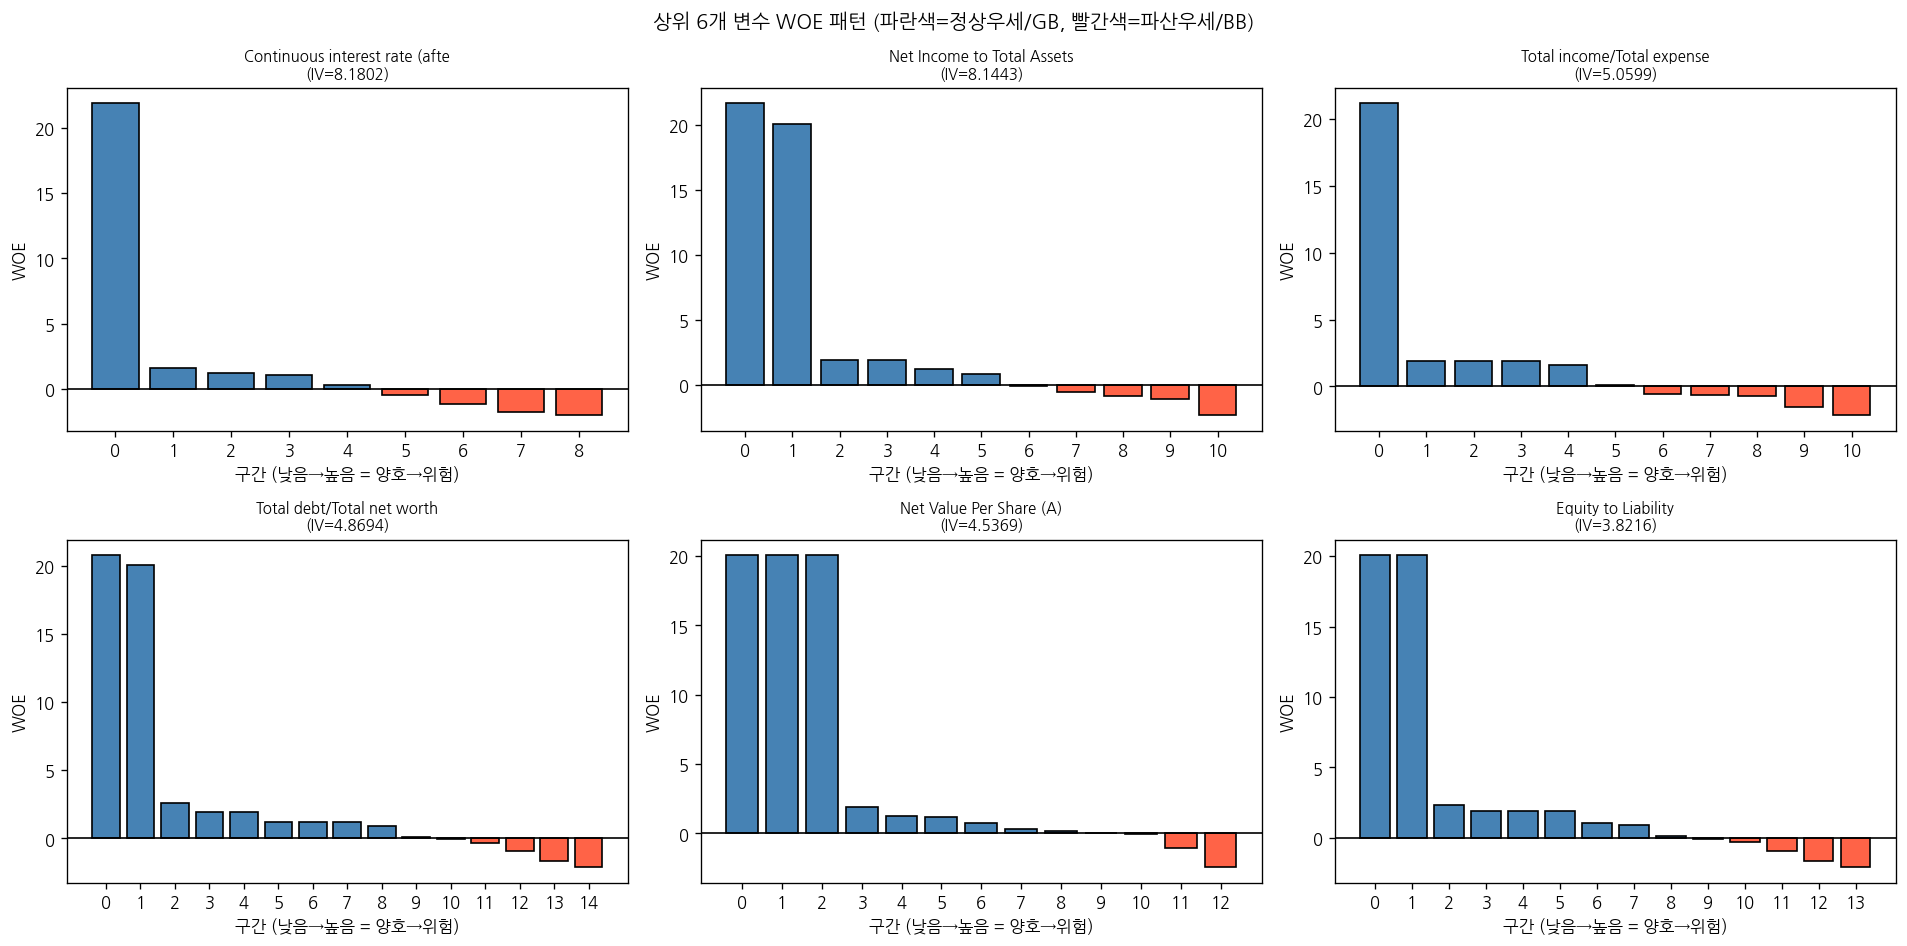

In [21]:
# Cell 14
# ─────────────────────────────────────────────────────────────
# WOE 재산출 및 시각화 (논문 기준)
#
# [논문 p.29, p.62, 표4-2 - 김종윤 2019]
# WOE(GB INDEX) = ln(p(good) / p(bad))
# - Fine Classing 결과표에 GB INDEX(WOE)와 KS가
#   컬럼으로 함께 산출됨 (논문 표4-2)
# - WOE 값이 높을수록(GB = Good Bias): 해당 구간 정상 가능성 높음
# - WOE 값이 낮을수록(BB = Bad Bias) : 해당 구간 파산 가능성 높음
# - 변수 변별력 패턴 확인 및 IV(Information Value) 산출
#
# [IV 해석 기준 - 실무 기준]
# IV < 0.02  : 예측력 없음
# 0.02~0.1   : 약한 예측력
# 0.1~0.3    : 중간 예측력
# 0.3 이상   : 강한 예측력
#
# [누수 방지] Train 데이터만 사용
# ─────────────────────────────────────────────────────────────

def calc_woe_train(feature):
    bin_edges, recode_map, nan_val = bin_info[feature]

    tmp_df = pd.DataFrame(
        {'recode': recoded_train[feature], 'target': y_train.values},
        index=recoded_train[feature].index)

    grouped = tmp_df.groupby('recode')['target'].agg(['sum', 'count'])
    grouped.columns = ['bad', 'count']
    grouped['good']     = grouped['count'] - grouped['bad']
    grouped['bad_rate'] = grouped['bad'] / grouped['count']

    total_good = grouped['good'].sum()
    total_bad  = grouped['bad'].sum()

    grouped['pct_good'] = grouped['good'] / max(total_good, 1)
    grouped['pct_bad']  = grouped['bad']  / max(total_bad,  1)
    grouped['pct_good'] = grouped['pct_good'].replace(0, 1e-10)
    grouped['pct_bad']  = grouped['pct_bad'].replace(0,  1e-10)
    grouped['WOE'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['IV']  = (grouped['pct_good'] - grouped['pct_bad']) * grouped['WOE']

    iv_total = grouped['IV'].sum()
    return grouped.reset_index(), iv_total


print("=== WOE 재산출 (Coarse Classing 완료 후, 논문 표4-2 형태) ===")
print("※ Train 데이터 기준 (누수 방지)\n")
print(f"{'변수명':<45} {'구간수':>5} {'WOE 범위':>22} {'IV':>8}")
print("-" * 85)

woe_tables = {}
iv_summary = {}

for col in features_for_recoding:
    if col not in recoded_train:
        continue
    tbl, iv_total = calc_woe_train(col)
    woe_tables[col] = tbl
    iv_summary[col] = iv_total

    woe_min = tbl['WOE'].min()
    woe_max = tbl['WOE'].max()
    print(f"{col[:43]:<45} {len(tbl):>5} "
          f"{woe_min:>8.4f} ~ {woe_max:>8.4f} {iv_total:>8.4f}")

# WOE 패턴 시각화 (IV 상위 6개)
iv_series = pd.Series(iv_summary).sort_values(ascending=False)
top6      = iv_series.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    tbl = woe_tables[col]
    axes[i].bar(range(len(tbl)), tbl['WOE'].values,
                color=['tomato' if w < 0 else 'steelblue'
                       for w in tbl['WOE'].values],
                edgecolor='black')
    axes[i].axhline(y=0, color='black', linewidth=1)
    axes[i].set_title(f"{col[:30]}\n(IV={iv_summary[col]:.4f})", fontsize=9)
    axes[i].set_xlabel('구간 (낮음→높음 = 양호→위험)')
    axes[i].set_ylabel('WOE')
    axes[i].set_xticks(range(len(tbl)))

plt.suptitle('상위 6개 변수 WOE 패턴 (파란색=정상우세/GB, 빨간색=파산우세/BB)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Cell 15
# ─────────────────────────────────────────────────────────────
# 단변량 유의성 스크리닝 (1차 부분 적합, 논문 기준)
#
# [논문 p.32 - 김종윤 2019]
# "로지스틱회귀모형 적합시 1차적으로 설명변수의
#  각 정보영역별로 부분 적합을 수행하여
#  유의미한 설명변수를 선별하고,
#  2차적으로 본 적합을 수행한다"
#
# 확인 조건 (논문 p.32):
# 1. 각 변수의 회귀계수가 유의수준 0.05 내에서 통계적으로 유의미
# 2. 각 변수의 회귀계수가 모두 양의 값
#    (Recoding 순서와 일치 — 불량률 높은 구간 = 높은 정수값 = 양수 계수)
#
# [누수 방지] Train 더미변수만 사용
# ─────────────────────────────────────────────────────────────
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("=== 단변량 유의성 스크리닝 (1차 부분 적합, 논문 p.32) ===")
print("기준: p-value < 0.05 AND 회귀계수 > 0 (양수)")
print("※ Train 데이터 기준 (누수 방지)\n")
print(f"{'변수명':<45} {'min p-val':>10} {'max coef':>10} {'유의':>6}")
print("-" * 76)

univariate_results = {}
selected_features  = []

for col in features_for_recoding:
    prefix     = col[:20]
    dummy_cols = [c for c in X_train.columns if c.startswith(prefix + '_')]

    if not dummy_cols:
        continue

    X_var       = X_train[dummy_cols].astype(float)
    X_var_const = sm.add_constant(X_var)

    try:
        model  = sm.Logit(y_train, X_var_const)
        result = model.fit(method='lbfgs', maxiter=500, disp=False)

        params   = result.params.drop('const', errors='ignore')
        pvals    = result.pvalues.drop('const', errors='ignore')
        sig_mask = (pvals < 0.05) & (params > 0)

        is_significant = sig_mask.any()

        if is_significant:
            min_pval = pvals[sig_mask].min()
            max_coef = params[sig_mask].max()
            selected_features.append(col)
            status = '✅'
        else:
            min_pval = pvals.min()
            max_coef = params.max()
            status   = '❌'

        univariate_results[col] = {
            'min_pval': min_pval,
            'max_coef': max_coef,
            'significant': is_significant
        }
        print(f"{status} {col[:43]:<43} {min_pval:>10.4f} {max_coef:>10.4f}")

    except Exception as e:
        print(f"⚠️  {col[:43]:<43} 적합실패: {str(e)[:20]}")

print(f"\n{'='*76}")
print(f"1차 부분 적합 결과: {len(features_for_recoding)}개 → {len(selected_features)}개 선별")

=== 단변량 유의성 스크리닝 (1차 부분 적합, 논문 p.32) ===
기준: p-value < 0.05 AND 회귀계수 > 0 (양수)
※ Train 데이터 기준 (누수 방지)

변수명                                            min p-val   max coef     유의
----------------------------------------------------------------------------
✅ ROA(C) before interest and depreciation bef     0.0000     5.5824
✅ ROA(A) before interest and % after tax          0.0000     5.4675
✅ ROA(B) before interest and depreciation aft     0.0000     6.0399
✅ Operating Gross Margin                          0.0000     2.9285
❌ Realized Sales Gross Margin                        nan     1.2096
❌ Operating Profit Rate                           0.6862     9.8651
✅ Pre-tax net Interest Rate                       0.0000     4.7090
✅ After-tax net Interest Rate                     0.0000     4.5038
✅ Non-industry income and expenditure/revenue     0.0000     3.9883
❌ Continuous interest rate (after tax)            0.6030    11.9955
✅ Cash flow rate                                  0.0000     2.781

상관분석 대상 변수: 62개
(Cell 15 단변량 스크리닝 통과 변수 자동 사용)

=== 상관분석 결과 (Train 기준, 논문 p.69) ===
기준: 상관계수 0.6 초과 쌍 확인
0.6 초과 고상관 쌍: 50개

                                                       var1                                               var2  correlation
15                                   Operating Gross Margin                              Gross Profit to Sales       1.0000
35                                    Net Value Growth Rate                     Quick Assets/Current Liability       1.0000
16                                Pre-tax net Interest Rate                        After-tax net Interest Rate       0.9999
32                         After-tax Net Profit Growth Rate                     Regular Net Profit Growth Rate       0.9965
1   ROA(C) before interest and depreciation before interest  ROA(B) before interest and depreciation after tax       0.9865
28                 Per Share Net profit before tax (Yuan ¥)              Net profit before tax/Paid-in capital       0.9857
24      

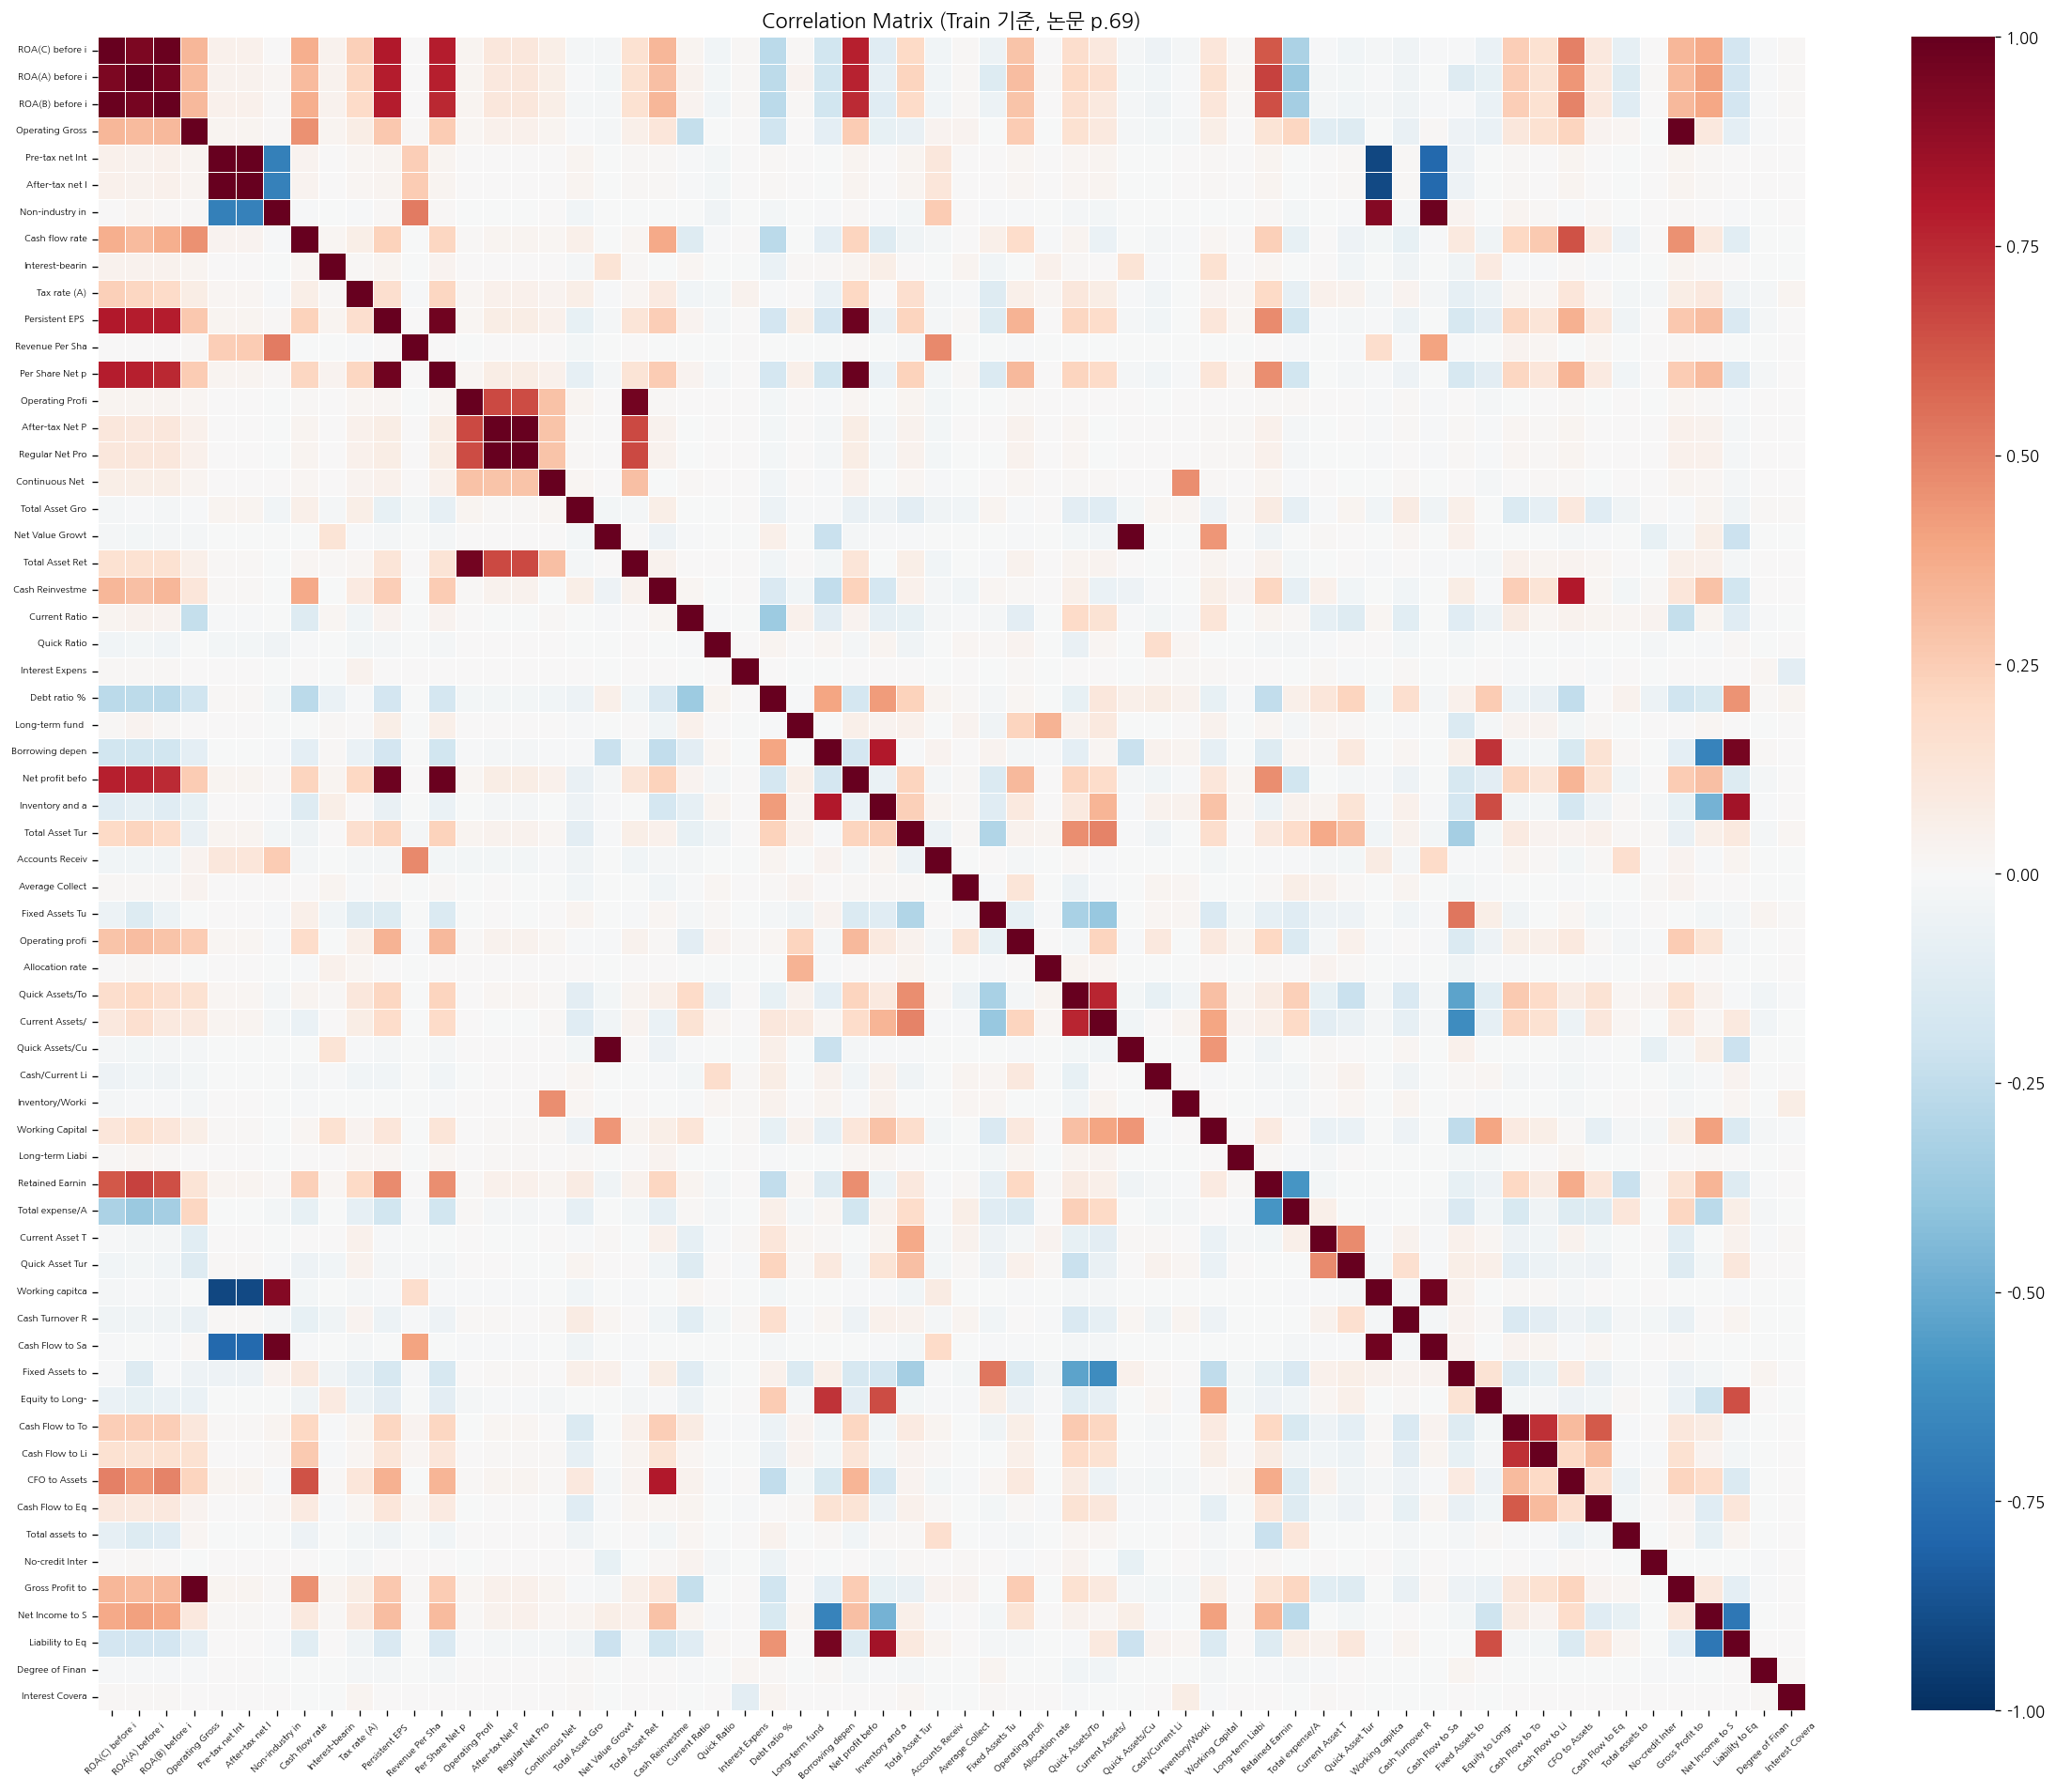

In [23]:
# Cell 16
# ─────────────────────────────────────────────────────────────
# 상관분석 (논문 기준)
#
# [논문 p.69 - 김종윤 2019]
# "최종적으로 선정된 개인신용평가모형을 구성하는 평가항목은
#  항목 간 상관관계가 낮아야 안정적이고
#  변별력 있는 모형으로 판단할 수 있으며
#  상관분석을 수행하였다"
# "상관계수 0.6 이하를 만족하고 있음을 보였다" (논문 p.69)
#
# [변수 선정 방식]
# Cell 15 단변량 스크리닝 통과 변수(selected_features)를
# 그대로 사용 → 하드코딩 없이 자동 연결
#
# [누수 방지] Train 기준 계산
# ─────────────────────────────────────────────────────────────

# Cell 15 결과에서 자동으로 가져옴 (하드코딩 제거)
selected_features_list = selected_features.copy()

print(f"상관분석 대상 변수: {len(selected_features_list)}개")
print("(Cell 15 단변량 스크리닝 통과 변수 자동 사용)\n")

X_selected_train = X_train_raw[selected_features_list].copy()
corr_matrix      = X_selected_train.corr().abs()

# 0.6 초과 쌍 추출
high_corr_pairs = []
for i in range(len(selected_features_list)):
    for j in range(i+1, len(selected_features_list)):
        r = corr_matrix.iloc[i, j]
        if r > 0.6:
            high_corr_pairs.append({
                'var1': selected_features_list[i],
                'var2': selected_features_list[j],
                'correlation': round(r, 4)
            })

high_corr_df = (pd.DataFrame(high_corr_pairs)
                .sort_values('correlation', ascending=False)
                if high_corr_pairs else pd.DataFrame())

print(f"=== 상관분석 결과 (Train 기준, 논문 p.69) ===")
print(f"기준: 상관계수 0.6 초과 쌍 확인")
print(f"0.6 초과 고상관 쌍: {len(high_corr_df)}개\n")

if len(high_corr_df) > 0:
    print(high_corr_df.to_string())

selected_features_2 = selected_features_list.copy()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    X_selected_train.corr(),
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.3,
    xticklabels=[c[:15] for c in selected_features_list],
    yticklabels=[c[:15] for c in selected_features_list],
    annot=False
)
ax.set_title('Correlation Matrix (Train 기준, 논문 p.69)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=6)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

In [24]:
# Cell 17
# ─────────────────────────────────────────────────────────────
# 다중공선성 처리 — 상관분석 결과 기반 자동 제거
#
# [논문 p.69 - 김종윤 2019]
# "상관계수 0.6 이하를 만족하고 있음을 보였다"
# → 논문에서는 VIF 계산을 별도로 수행하지 않음
# → 상관분석(Cell 16)에서 0.6 초과 쌍을 확인하고
#   업무적 판단으로 제거 변수 결정
#
# [자동화 방식]
# Cell 16의 high_corr_df(고상관 쌍)를 기반으로
# 상관계수 높은 순으로 한 쪽을 자동 제거
# → 제거 기준: 각 고상관 쌍에서 더 많은 쌍에 등장하는 변수 제거
#              (연결 수가 같으면 var2 제거)
#
# [수동 오버라이드]
# 자동 제거 결과가 맞지 않으면
# manual_remove 리스트에 직접 추가/수정 가능
# ─────────────────────────────────────────────────────────────

# ── 자동 제거 로직 ────────────────────────────────────────────────────
def auto_remove_high_corr(high_corr_df, threshold=0.6):
    """
    고상관 쌍에서 연결 수가 많은 변수를 우선 제거
    → 제거 후 남은 쌍 재확인 반복
    """
    if high_corr_df.empty:
        return []

    removed = []
    pairs   = list(zip(high_corr_df['var1'],
                       high_corr_df['var2'],
                       high_corr_df['correlation']))

    while pairs:
        # 현재 쌍에서 각 변수 등장 횟수 집계
        from collections import Counter
        counter = Counter()
        for v1, v2, _ in pairs:
            counter[v1] += 1
            counter[v2] += 1

        # 가장 많이 등장하는 변수 제거 (동점이면 첫 번째 쌍의 var2)
        most_common = counter.most_common()
        max_count   = most_common[0][1]
        candidates  = [v for v, c in most_common if c == max_count]

        # 동점 시 첫 번째 쌍 기준으로 var2 우선 제거
        to_drop = None
        for v1, v2, _ in pairs:
            if v2 in candidates:
                to_drop = v2
                break
            if v1 in candidates:
                to_drop = v1
                break

        removed.append(to_drop)
        # 제거된 변수가 포함된 쌍 전부 제거
        pairs = [(v1, v2, r) for v1, v2, r in pairs
                 if v1 != to_drop and v2 != to_drop]

    return removed

auto_removed = auto_remove_high_corr(high_corr_df)

print("=== 자동 제거 결과 (상관계수 0.6 초과 기준) ===")
print(f"자동 제거 변수 ({len(auto_removed)}개):")
for i, v in enumerate(auto_removed, 1):
    print(f"  {i:2d}. {v}")

# ── 수동 오버라이드 (필요 시 직접 수정) ──────────────────────────────
# 자동 제거 결과가 업무적으로 맞지 않으면 아래에서 조정
# 예시: manual_add    = ['변수명']  → 추가 제거
#       manual_remove = ['변수명']  → 자동 제거 취소 (복원)

manual_add    = []  # 추가로 제거할 변수
manual_remove = []  # 자동 제거 취소할 변수 (복원)

to_remove = [v for v in auto_removed if v not in manual_remove] + manual_add
to_remove  = list(dict.fromkeys(to_remove))  # 중복 제거

if manual_add or manual_remove:
    print(f"\n수동 조정:")
    if manual_add:
        print(f"  추가 제거: {manual_add}")
    if manual_remove:
        print(f"  복원:      {manual_remove}")

# ── 최종 변수 리스트 업데이트 ─────────────────────────────────────────
selected_features_2 = [f for f in selected_features_2
                        if f not in to_remove]

print(f"\n=== 다중공선성 처리 결과 (논문 p.69) ===")
print(f"제거 변수 수: {len(to_remove)}개")
print(f"잔여 변수:    {len(selected_features_2)}개")
print(f"\n잔여 변수 목록:")
for i, v in enumerate(selected_features_2, 1):
    print(f"  {i:2d}. {v}")
'''

---

이렇게 하면:

Cell 16: selected_features (Cell 15 결과) → 자동 연결
Cell 17: high_corr_df (Cell 16 결과) → 자동 제거 로직
         manual_add / manual_remove 로 수동 조정만 필요
'''

=== 자동 제거 결과 (상관계수 0.6 초과 기준) ===
자동 제거 변수 (20개):
   1. ROA(B) before interest and depreciation after tax
   2. ROA(A) before interest and % after tax
   3. After-tax net Interest Rate
   4. Liability to Equity
   5. ROA(C) before interest and depreciation before interest
   6. Regular Net Profit Growth Rate
   7. Cash Flow to Sales
   8. Borrowing dependency
   9. Net profit before tax/Paid-in capital
  10. Total Asset Return Growth Rate Ratio
  11. Working capitcal Turnover Rate
  12. CFO to Assets
  13. Current Assets/Total Assets
  14. Cash Flow to Total Assets
  15. Gross Profit to Sales
  16. Quick Assets/Current Liability
  17. Per Share Net profit before tax (Yuan ¥)
  18. Non-industry income and expenditure/revenue
  19. After-tax Net Profit Growth Rate
  20. Equity to Long-term Liability

=== 다중공선성 처리 결과 (논문 p.69) ===
제거 변수 수: 20개
잔여 변수:    42개

잔여 변수 목록:
   1. Operating Gross Margin
   2. Pre-tax net Interest Rate
   3. Cash flow rate
   4. Interest-bearing debt interest rat

'\n\n---\n\n이렇게 하면:\n\nCell 16: selected_features (Cell 15 결과) → 자동 연결\nCell 17: high_corr_df (Cell 16 결과) → 자동 제거 로직\n         manual_add / manual_remove 로 수동 조정만 필요\n'

In [25]:
# Cell 18
# ─────────────────────────────────────────────────────────────
# VIF 기반 다중공선성 추가 제거
#
# [논문 p.69 보완]
# 논문에서는 상관계수 0.6 기준만 명시하였으나,
# 수작업 제거 후에도 다중공선성이 남아있을 수 있음
# → VIF(Variance Inflation Factor) > 5 기준으로 반복 제거
# → VIF > 10이면 심각한 다중공선성,
#   VIF > 5면 주의 수준 (실무 기준)
#
# [누수 방지] Train 기준 계산
# ─────────────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

def calc_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF']     = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

X_vif = X_train_raw[selected_features_2].copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.median())

vif_removed = []
iteration   = 0

print("=== VIF 기반 다중공선성 추가 제거 (기준: VIF > 5) ===\n")

while True:
    iteration += 1
    vif_df      = calc_vif(X_vif)
    max_vif     = vif_df.iloc[0]['VIF']
    max_feature = vif_df.iloc[0]['feature']

    print(f"[Iteration {iteration}] 최대 VIF: {max_feature} = {max_vif:.2f}")

    if max_vif <= 5:
        print(f"\n✅ 모든 변수 VIF ≤ 5 달성 → 반복 종료")
        break

    vif_removed.append(max_feature)
    X_vif = X_vif.drop(columns=[max_feature])

selected_features_3 = list(X_vif.columns)

print(f"\n=== VIF 제거 결과 ===")
print(f"VIF > 5로 추가 제거된 변수 ({len(vif_removed)}개): {vif_removed}")
print(f"최종 잔여 변수: {len(selected_features_3)}개\n")
print("최종 변수 목록:")
for i, f in enumerate(selected_features_3, 1):
    print(f"  {i:2d}. {f}")

print(f"\n=== 최종 VIF 테이블 ===")
print(calc_vif(X_vif).to_string(index=False))

=== VIF 기반 다중공선성 추가 제거 (기준: VIF > 5) ===

[Iteration 1] 최대 VIF: Operating Profit Growth Rate = 4210.73
[Iteration 2] 최대 VIF: Pre-tax net Interest Rate = 3659.25
[Iteration 3] 최대 VIF: Retained Earnings to Total Assets = 2874.94
[Iteration 4] 최대 VIF: Interest Expense Ratio = 2680.12
[Iteration 5] 최대 VIF: Operating Gross Margin = 2259.36
[Iteration 6] 최대 VIF: Cash Flow to Liability = 310.51
[Iteration 7] 최대 VIF: Persistent EPS in the Last Four Seasons = 82.15
[Iteration 8] 최대 VIF: Debt ratio % = 11.31
[Iteration 9] 최대 VIF: Fixed Assets to Assets = 4.98

✅ 모든 변수 VIF ≤ 5 달성 → 반복 종료

=== VIF 제거 결과 ===
VIF > 5로 추가 제거된 변수 (8개): ['Operating Profit Growth Rate', 'Pre-tax net Interest Rate', 'Retained Earnings to Total Assets', 'Interest Expense Ratio', 'Operating Gross Margin', 'Cash Flow to Liability', 'Persistent EPS in the Last Four Seasons', 'Debt ratio %']
최종 잔여 변수: 34개

최종 변수 목록:
   1. Cash flow rate
   2. Interest-bearing debt interest rate
   3. Tax rate (A)
   4. Revenue Per Share (Yuan

In [26]:
# Cell 19
# ─────────────────────────────────────────────────────────────
# 2차 본 적합 — 최종 변수 선별 (논문 기준)
#
# [논문 p.32 - 김종윤 2019]
# "2차 본 적합은 1차 부분 적합에서 선별된 변수를
#  모두 투입하여 로지스틱 회귀를 수행한다"
# "각 변수의 회귀계수가 유의수준 0.05 내에서 유의미하고
#  계수가 양의 값인 변수만 최종 선별한다" (논문 p.32)
#
# [VIF 필터링 결과 사용]
# Cell 18에서 VIF > 5 제거 후 남은 selected_features_3 투입
#
# [최종 선별 기준]
# - p-value < 0.05 (통계적 유의성)
# - 계수 > 0 (Recoding 단조성과 방향 일치)
# ─────────────────────────────────────────────────────────────
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

final_dummy_cols   = []
feature_to_dummies = {}

for col in selected_features_3:
    dummy_cols = [c for c in X_train.columns if c.startswith(col + '_')]

    if dummy_cols:
        final_dummy_cols.extend(dummy_cols)
        feature_to_dummies[col] = dummy_cols
    elif col in X_train.columns:
        final_dummy_cols.append(col)
        feature_to_dummies[col] = [col]
    else:
        prefix         = col[:20]
        dummy_cols_fb  = [c for c in X_train.columns
                          if c.startswith(prefix + '_')]
        if dummy_cols_fb:
            final_dummy_cols.extend(dummy_cols_fb)
            feature_to_dummies[col] = dummy_cols_fb
        else:
            print(f"⚠️ 매핑 실패: {col}")
            feature_to_dummies[col] = []

final_dummy_cols = list(dict.fromkeys(final_dummy_cols))

X_train_final   = X_train[final_dummy_cols].astype(float)
X_holdout_final = X_holdout[final_dummy_cols].astype(float)
X_oot_final     = X_oot[final_dummy_cols].astype(float)

print(f"투입 변수(selected_features_3): {len(selected_features_3)}개")
print(f"투입 더미변수 컬럼: {X_train_final.shape[1]}개\n")

X_2nd_const = sm.add_constant(X_train_final)

print("2차 본 적합 진행 중...")
result_2nd = None
for method in ['lbfgs', 'newton', 'bfgs']:
    try:
        model_2nd  = sm.Logit(y_train, X_2nd_const)
        result_2nd = model_2nd.fit(method=method, maxiter=1000, disp=False)
        print(f"✅ 적합 완료 (method={method})\n")
        break
    except Exception as e:
        print(f"  {method} 실패: {e}")

if result_2nd is None:
    print("❌ 모든 방법 실패")
else:
    summary = pd.DataFrame({
        'coef':   result_2nd.params,
        'pvalue': result_2nd.pvalues
    }).drop('const', errors='ignore')

    print("=== 전체 계수 요약 ===")
    print(summary.round(4).to_string())
    print()

    significant_idx = set(
        summary[(summary['pvalue'] < 0.05) & (summary['coef'] > 0)].index)

    final_selected = []
    not_selected   = []

    for col in selected_features_3:
        dummies = feature_to_dummies.get(col, [])
        if any(d in significant_idx for d in dummies):
            final_selected.append(col)
        else:
            not_selected.append(col)

    print(f"=== 2차 본 적합 결과 (논문 p.32) ===")
    print(f"투입: {len(selected_features_3)}개 → 최종 선별: {len(final_selected)}개\n")

    print("✅ 최종 선별 변수:")
    for i, f in enumerate(final_selected, 1):
        print(f"  {i:2d}. {f}")

    print(f"\n❌ 탈락 변수 ({len(not_selected)}개):")
    for f in not_selected:
        dummies   = feature_to_dummies.get(f, [])
        coef_info = ""
        for d in dummies:
            if d in summary.index:
                coef_info += (f" | coef={summary.loc[d,'coef']:.4f},"
                              f" p={summary.loc[d,'pvalue']:.4f}")
        print(f"  - {f}{coef_info}")

투입 변수(selected_features_3): 34개
투입 더미변수 컬럼: 190개

2차 본 적합 진행 중...
✅ 적합 완료 (method=lbfgs)

=== 전체 계수 요약 ===
                          coef  pvalue
Cash flow rate_1       -0.8157  0.6575
Cash flow rate_2       -1.3250  0.2092
Cash flow rate_3       -1.1428  0.2689
Cash flow rate_4       -0.9168  0.4420
Cash flow rate_5       -1.4310  0.2524
Cash flow rate_6       -0.7446  0.5765
Cash flow rate_7        1.0726  0.4887
Interest-bearing deb_1  1.5407  0.2532
Interest-bearing deb_2  1.2373  0.4133
Interest-bearing deb_3  1.2487  0.3122
Interest-bearing deb_4  1.4517  0.2644
Interest-bearing deb_5  1.9578  0.1096
Interest-bearing deb_6  2.4925  0.0432
Tax rate (A)_1          0.1050  0.9260
Tax rate (A)_2          1.0926  0.1646
Tax rate (A)_3          0.3151  0.6247
Revenue Per Share (Y_1  1.5646  0.1885
Revenue Per Share (Y_2  1.9802  0.1005
Revenue Per Share (Y_3  2.1125  0.0877
Revenue Per Share (Y_4  2.2890  0.0796
Revenue Per Share (Y_5  1.6200  0.2682
Revenue Per Share (Y_6  1.6245  0.2

최종 선별 변수: 11개
투입 더미컬럼:  65개

=== 단일 모형 성능 검증 (NICE 기준) ===

샘플                AUC       KS     KS판단       AR     AR판단
------------------------------------------------------------
Train          0.9370    75.10        ✅    87.40        ✅
Hold-Out       0.8722    65.53        ✅    74.43        ✅
OOT            0.8960    64.92        ✅    79.21        ✅

=== NICE 성능지표 판단 ===
KS ≥ 20 (HO+OOT): ✅ 충족
AR ≥ 30 (HO+OOT): ✅ 충족
PSI        : ⚠️ 산출 불가 (단일 시점 데이터)


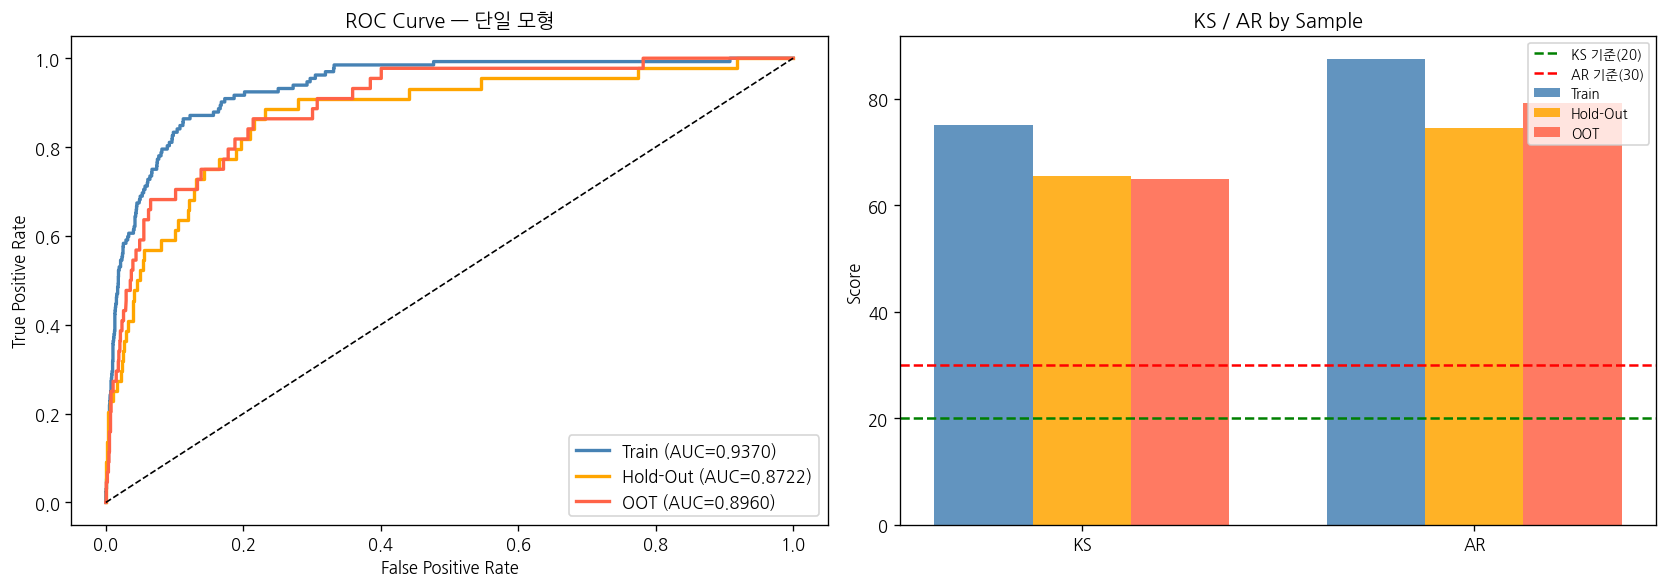

In [43]:
# Cell 20
# ─────────────────────────────────────────────────────────────
# 단일 모형 성능 검증 (논문 기준)
#
# [논문 p.35-36 - 김종윤 2019]
# KS 통계량:
#   "우량/불량 집단 누적분포 차이의 최대값"
#   "일반적으로 40% 이상일 경우 변별력이 확보됐다고 판단" (논문 p.36)
#   논문 실제 결과: 금융이력보유 KS=43.07% (논문 표4-11)
# AR(Accuracy Ratio):
#   "CAP 곡선으로부터 도출, 30% 이상이면 유의한 모형" (NICE 공시)
# PSI(Population Stability Index):
#   "PSI ≤ 0.15: 최종모형으로 선택가능" (논문 표2-7)
#   → 단일 시점 데이터 랜덤 분할 구조로 시계열 PSI 산출 불가
#
# [모형 방법론 결정 과정]
# 1. balanced(class_weight='balanced') 시도
#    → HO/OOT에서 AAA 등급 쏠림(57%) 문제 발생
# 2. 순수 로지스틱(class_weight=None) 채택
#    → KS/AR 성능 동등 또는 우수 (HO: KS 59.70→66.21)
#    → 확률값이 실제 부도율에 가깝게 형성
#    → 방법론 단순성 확보
#
# [누수 방지] HO/OOT는 Train 학습 결과만 적용
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import warnings
warnings.filterwarnings('ignore')

final_dummy_cols = []
for col in final_selected:
    dummies = feature_to_dummies.get(col, [])
    if dummies:
        final_dummy_cols.extend(dummies)
    else:
        print(f"⚠️ 매핑 없음: {col}")

final_dummy_cols = list(dict.fromkeys(final_dummy_cols))

X_tr = X_train[final_dummy_cols].astype(float)
X_ho = X_holdout[final_dummy_cols].astype(float)
X_ot = X_oot[final_dummy_cols].astype(float)

print(f"최종 선별 변수: {len(final_selected)}개")
print(f"투입 더미컬럼:  {len(final_dummy_cols)}개\n")

lr = LogisticRegression(
    class_weight=None, max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_tr, y_train)

prob_train   = lr.predict_proba(X_tr)[:, 1]
prob_holdout = lr.predict_proba(X_ho)[:, 1]
prob_oot     = lr.predict_proba(X_ot)[:, 1]

# KS 계산 (NICE 방식: 고위험부터 누적)
def calc_ks_nice(y_true, y_prob):
    """
    확률값 기반 KS 계산 (정보 손실 없는 정확한 버전)

    [NICE 공식 정의]
    "누적 우량비율과 누적 불량비율 차이의 최대값"
    → 부도확률 내림차순 정렬 후 각 지점에서 계산
    → 20분위 구간화 제거 (정보 손실 방지)
    """
    y_true = np.array(y_true)

    # 부도확률 내림차순 정렬
    sorted_idx = np.argsort(y_prob)[::-1]
    y_sorted   = y_true[sorted_idx]

    total_bad  = y_true.sum()
    total_good = (1 - y_true).sum()

    if total_bad == 0 or total_good == 0:
        return 0.0

    # 각 지점에서 누적 불량비율 - 누적 우량비율
    cum_bad  = np.cumsum(y_sorted)       / total_bad
    cum_good = np.cumsum(1 - y_sorted)   / total_good

    ks = np.max(np.abs(cum_bad - cum_good))
    return round(ks * 100, 2)

# AR 계산 (2*AUC - 1)
def calc_ar(y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    return round((2 * auc - 1) * 100, 2)

KS_THRESHOLD = 20
AR_THRESHOLD = 30

print("=== 단일 모형 성능 검증 (NICE 기준) ===\n")

results = {}
for name, y_true, y_prob in [
    ('Train',    y_train,   prob_train),
    ('Hold-Out', y_holdout, prob_holdout),
    ('OOT',      y_oot,     prob_oot),
]:
    auc = round(roc_auc_score(y_true, y_prob), 4)
    ks  = calc_ks_nice(y_true, y_prob)
    ar  = calc_ar(y_true, y_prob)
    results[name] = {'AUC': auc, 'KS': ks, 'AR': ar}

print(f"{'샘플':<12} {'AUC':>8} {'KS':>8} {'KS판단':>8} {'AR':>8} {'AR판단':>8}")
print("-" * 60)
for name in ['Train', 'Hold-Out', 'OOT']:
    r = results[name]
    print(f"{name:<12} {r['AUC']:>8.4f} {r['KS']:>8.2f} "
          f"{'✅' if r['KS'] >= KS_THRESHOLD else '❌':>8} "
          f"{r['AR']:>8.2f} "
          f"{'✅' if r['AR'] >= AR_THRESHOLD else '❌':>8}")

all_ks_ok = all(results[n]['KS'] >= KS_THRESHOLD for n in ['Hold-Out', 'OOT'])
all_ar_ok = all(results[n]['AR'] >= AR_THRESHOLD for n in ['Hold-Out', 'OOT'])
print(f"\n=== NICE 성능지표 판단 ===")
print(f"KS ≥ {KS_THRESHOLD} (HO+OOT): {'✅ 충족' if all_ks_ok else '❌ 미충족'}")
print(f"AR ≥ {AR_THRESHOLD} (HO+OOT): {'✅ 충족' if all_ar_ok else '❌ 미충족'}")
print(f"PSI        : ⚠️ 산출 불가 (단일 시점 데이터)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'orange', 'tomato']

for (name, y_true, y_prob), color in zip([
    ('Train',    y_train,   prob_train),
    ('Hold-Out', y_holdout, prob_holdout),
    ('OOT',      y_oot,     prob_oot),
], colors):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{name} (AUC={results[name]['AUC']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC Curve — 단일 모형', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

metrics = ['KS', 'AR']
x       = np.arange(len(metrics))
width   = 0.25
for i, (name, color) in enumerate(zip(['Train', 'Hold-Out', 'OOT'], colors)):
    vals = [results[name]['KS'], results[name]['AR']]
    axes[1].bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

axes[1].axhline(y=KS_THRESHOLD, color='green', linestyle='--',
                linewidth=1.5, label=f'KS 기준({KS_THRESHOLD})')
axes[1].axhline(y=AR_THRESHOLD, color='red', linestyle='--',
                linewidth=1.5, label=f'AR 기준({AR_THRESHOLD})')
axes[1].set_title('KS / AR by Sample', fontsize=12)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [44]:
# Cell 21
# ─────────────────────────────────────────────────────────────
# NICE 등급 매핑 → Cell 26으로 이동
#
# [이동 사유]
# 본 프로젝트의 1차 목표는 기업별 부도확률 도출임.
# 등급 매핑은 부도확률 확정(Cell 25) 후
# 확률 분포를 확인하고 사후적으로 수행하는 것이 적절함.
#
# [한계점 — 향후 반영 시 참고]
# 1. 모형 출력 확률이 전반적으로 높게 형성됨
#    (Train p1=0.0072 → NICE 등급 경계 AAA 0.001 미달)
#    → 상장기업 특성 + WOE 불균형 Over-estimation 가능성
# 2. 부도 샘플 176개(Train 132개)로 10등급 전부 채우기 어려움
#    → 상위 등급(AAA~A) 공백 불가피
# 3. 향후 권장: 분위수 기반 5~6등급 축소 또는
#    사후 확률 분포 확인 후 bin_edges 재설정
# ─────────────────────────────────────────────────────────────
print("Cell 21: NICE 등급 매핑 → Cell 26으로 이동")
print("→ Cell 25 (최종 출력) 완료 후 실행할 것")

Cell 21: NICE 등급 매핑 → Cell 26으로 이동
→ Cell 25 (최종 출력) 완료 후 실행할 것


=== 재무/비재무 분류 결과 ===

재무 변수 (9개):
  - Interest-bearing debt interest rate
  - Total Asset Growth Rate
  - Quick Ratio
  - Fixed Assets Turnover Frequency
  - Long-term Liability to Current Assets
  - Total expense/Assets
  - Current Asset Turnover Rate
  - Total assets to GNP price
  - Net Income to Stockholder's Equity

비재무 변수 (2개):
  - Operating profit per person
  - Allocation rate per person

[한계점] 현금흐름 변수: 2차 본 적합(Cell 19)에서 전부 탈락
  → NICE 공시 현금흐름 지표(손익활동CF/매출액 등) 반영 불가
  → 추후 파생변수 추가 시 현금흐름 영역 보완 가능

재무 더미컬럼:   53개
비재무 더미컬럼: 12개

=== 재무 모형 성능 ===
샘플                AUC       KS       AR
----------------------------------------
Train          0.9302    73.43    86.05
Hold-Out       0.8707    63.33    74.13
OOT            0.8946    66.74    78.92

=== 비재무 모형 성능 ===
샘플                AUC       KS       AR
----------------------------------------
Train          0.8263    56.48    65.27
Hold-Out       0.8119    51.89    62.37
OOT            0.8001    51.97    60.03

=== 결합 모형 성능 (재무 70

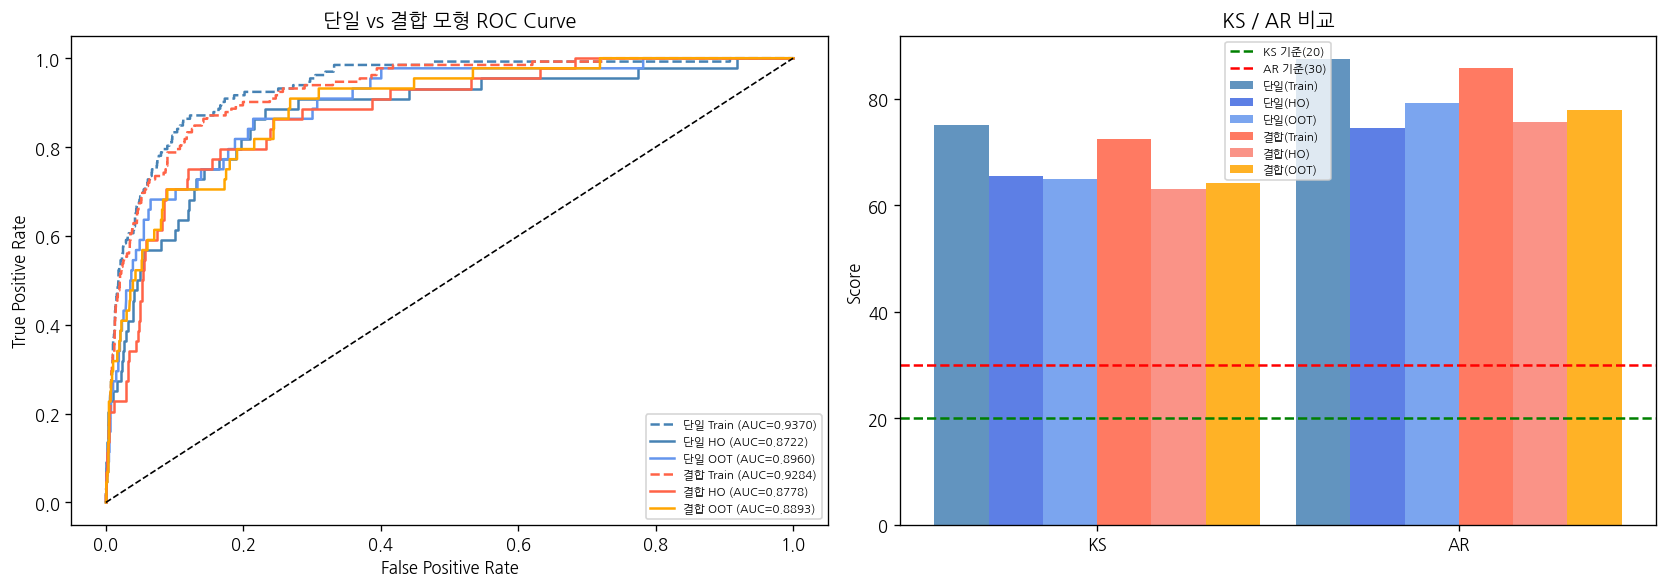

In [45]:
# Cell 22
# ─────────────────────────────────────────────────────────────
# 재무/비재무 분리 모형 적합 및 결합 모형 (논문 기준)
#
# [논문 p.32 - 김종윤 2019]
# "로지스틱 회귀 1차 부분 적합: 각 정보 영역별로 수행"
#
# [NICE 공시 기준 — 재무 계량모형 평가지표]
# 성장성: 매출액증가율 등
# 수익성: 기업순이익률 등
# 안정성: 금융비용 대 매출액 등
# 활동성: 총 자산 회전율 등
# 현금흐름: 손익활동CF/매출액 등
#
# [NICE 공시 기준 — 비재무 계량모형 평가지표]
# 경영자능력, 규모, 업력 등 재무제표 외 계량 지표
#
# [변수 분류 — final_selected 11개, 재무적 의미 기반 수동 분류]
# ┌─────────────────────────────────────────────────────────┐
# │ 성장성(1): Total Asset Growth Rate                      │
# │           → 총자산증가율: 기업 외형 성장 정도           │
# │                                                         │
# │ 수익성(3): Total expense/Assets                         │
# │           → 총비용/자산: 비용효율성                     │
# │           Net Income to Stockholder's Equity            │
# │           → ROE: 자기자본 대비 순이익(수익성 핵심)      │
# │           Total assets to GNP price                     │
# │           → GNP 대비 자산규모: 거시경제 대비 수익창출   │
# │                                                         │
# │ 안정성(3): Interest-bearing debt interest rate          │
# │           → 이자부담부채 이자율: 금융비용 부담 수준     │
# │           Quick Ratio                                   │
# │           → 당좌비율: 단기 유동성 및 지급능력           │
# │           Long-term Liability to Current Assets         │
# │           → 장기부채/유동자산: 장기 재무구조 건전성     │
# │                                                         │
# │ 활동성(2): Fixed Assets Turnover Frequency              │
# │           → 고정자산회전율: 고정자산 활용 효율          │
# │           Current Asset Turnover Rate                   │
# │           → 유동자산회전율: 유동자산 활용 효율          │
# │                                                         │
# │ 현금흐름(0): 해당 변수 없음                             │
# │           → 2차 본 적합에서 현금흐름 변수 전부 탈락     │
# │           → 한계점으로 명시                             │
# │                                                         │
# │ 비재무(2): Operating profit per person                  │
# │           → 인당영업이익: 인적 생산성 효율성            │
# │           Allocation rate per person                    │
# │           → 인당배분율: 인적자원 배분/처우 수준         │
# └─────────────────────────────────────────────────────────┘
#
# [누수 방지] 재무/비재무 모형 모두 Train만으로 적합
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 변수 영역 분류 (재무적 의미 기반 수동 분류) ──────────────────────
financial_vars = [v for v in final_selected
                  if v not in [
                      'Operating profit per person',
                      'Allocation rate per person'
                  ]]

non_financial_vars = [
    'Operating profit per person',   # 인당영업이익 (인적 생산성)
    'Allocation rate per person',    # 인당배분율 (인적자원 배분/처우)
]
# final_selected에 있는 것만 유지
non_financial_vars = [v for v in non_financial_vars if v in final_selected]

print("=== 재무/비재무 분류 결과 ===")
print(f"\n재무 변수 ({len(financial_vars)}개):")
for v in financial_vars:
    print(f"  - {v}")
print(f"\n비재무 변수 ({len(non_financial_vars)}개):")
for v in non_financial_vars:
    print(f"  - {v}")
print(f"\n[한계점] 현금흐름 변수: 2차 본 적합(Cell 19)에서 전부 탈락")
print(f"  → NICE 공시 현금흐름 지표(손익활동CF/매출액 등) 반영 불가")
print(f"  → 추후 파생변수 추가 시 현금흐름 영역 보완 가능")

# ── 더미컬럼 추출 ─────────────────────────────────────────────────────
def get_dummy_cols(var_list, feature_to_dummies):
    cols = []
    for col in var_list:
        dummies = feature_to_dummies.get(col, [])
        if dummies:
            cols.extend(dummies)
        else:
            print(f"⚠️ 매핑 없음: {col}")
    return list(dict.fromkeys(cols))

fin_cols  = get_dummy_cols(financial_vars,     feature_to_dummies)
nfin_cols = get_dummy_cols(non_financial_vars, feature_to_dummies)

print(f"\n재무 더미컬럼:   {len(fin_cols)}개")
print(f"비재무 더미컬럼: {len(nfin_cols)}개")

# ── 재무 모형 적합 (Train만) ──────────────────────────────────────────
lr_fin = LogisticRegression(
    class_weight=None, max_iter=1000, random_state=42, solver='lbfgs')
lr_fin.fit(X_train[fin_cols].astype(float), y_train)

prob_fin_tr = lr_fin.predict_proba(X_train[fin_cols].astype(float))[:, 1]
prob_fin_ho = lr_fin.predict_proba(X_holdout[fin_cols].astype(float))[:, 1]
prob_fin_ot = lr_fin.predict_proba(X_oot[fin_cols].astype(float))[:, 1]

print("\n=== 재무 모형 성능 ===")
print(f"{'샘플':<12} {'AUC':>8} {'KS':>8} {'AR':>8}")
print("-" * 40)
for name, y_true, y_prob in [
    ('Train',    y_train,   prob_fin_tr),
    ('Hold-Out', y_holdout, prob_fin_ho),
    ('OOT',      y_oot,     prob_fin_ot),
]:
    auc = round(roc_auc_score(y_true, y_prob), 4)
    ks  = calc_ks_nice(y_true, y_prob)
    ar  = calc_ar(y_true, y_prob)
    print(f"{name:<12} {auc:>8.4f} {ks:>8.2f} {ar:>8.2f}")

# ── 비재무 모형 적합 (Train만) ────────────────────────────────────────
if nfin_cols:
    lr_nfin = LogisticRegression(
        class_weight=None, max_iter=1000, random_state=42, solver='lbfgs')
    lr_nfin.fit(X_train[nfin_cols].astype(float), y_train)

    prob_nfin_tr = lr_nfin.predict_proba(X_train[nfin_cols].astype(float))[:, 1]
    prob_nfin_ho = lr_nfin.predict_proba(X_holdout[nfin_cols].astype(float))[:, 1]
    prob_nfin_ot = lr_nfin.predict_proba(X_oot[nfin_cols].astype(float))[:, 1]

    print("\n=== 비재무 모형 성능 ===")
    print(f"{'샘플':<12} {'AUC':>8} {'KS':>8} {'AR':>8}")
    print("-" * 40)
    for name, y_true, y_prob in [
        ('Train',    y_train,   prob_nfin_tr),
        ('Hold-Out', y_holdout, prob_nfin_ho),
        ('OOT',      y_oot,     prob_nfin_ot),
    ]:
        auc = round(roc_auc_score(y_true, y_prob), 4)
        ks  = calc_ks_nice(y_true, y_prob)
        ar  = calc_ar(y_true, y_prob)
        print(f"{name:<12} {auc:>8.4f} {ks:>8.2f} {ar:>8.2f}")
else:
    prob_nfin_tr = prob_fin_tr
    prob_nfin_ho = prob_fin_ho
    prob_nfin_ot = prob_fin_ot
    print("\n⚠️ 비재무 변수 없음 → 비재무 확률 = 재무 확률로 대체")

# ── 결합 모형 (재무 70% + 비재무 30%) ────────────────────────────────
W_FIN  = 0.7
W_NFIN = 0.3

prob_combined_tr = W_FIN * prob_fin_tr + W_NFIN * prob_nfin_tr
prob_combined_ho = W_FIN * prob_fin_ho + W_NFIN * prob_nfin_ho
prob_combined_ot = W_FIN * prob_fin_ot + W_NFIN * prob_nfin_ot

print("\n=== 결합 모형 성능 (재무 70% + 비재무 30%) ===")
print(f"{'샘플':<12} {'AUC':>8} {'KS':>8} {'AR':>8} {'KS판단':>8} {'AR판단':>8}")
print("-" * 60)

results_combined = {}
for name, y_true, y_prob in [
    ('Train',    y_train,   prob_combined_tr),
    ('Hold-Out', y_holdout, prob_combined_ho),
    ('OOT',      y_oot,     prob_combined_ot),
]:
    auc = round(roc_auc_score(y_true, y_prob), 4)
    ks  = calc_ks_nice(y_true, y_prob)
    ar  = calc_ar(y_true, y_prob)
    results_combined[name] = {'AUC': auc, 'KS': ks, 'AR': ar}
    print(f"{name:<12} {auc:>8.4f} {ks:>8.2f} {ar:>8.2f} "
          f"{'✅' if ks >= 20 else '❌':>8} {'✅' if ar >= 30 else '❌':>8}")

print("\n=== 단일 vs 결합 모형 비교 ===")
print(f"{'구분':<20} {'AUC':>8} {'KS':>8} {'AR':>8}")
print("-" * 48)
for label, res in [
    ('단일 (Train)', results['Train']),
    ('단일 (HO)',    results['Hold-Out']),
    ('단일 (OOT)',   results['OOT']),
    ('결합 (Train)', results_combined['Train']),
    ('결합 (HO)',    results_combined['Hold-Out']),
    ('결합 (OOT)',   results_combined['OOT']),
]:
    print(f"{label:<20} {res['AUC']:>8.4f} {res['KS']:>8.2f} {res['AR']:>8.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, y_true, y_prob, color, ls in [
    ('단일 Train',  y_train,   prob_train,       'steelblue',      '--'),
    ('단일 HO',     y_holdout, prob_holdout,     'steelblue',      '-'),
    ('단일 OOT',    y_oot,     prob_oot,         'cornflowerblue', '-'),
    ('결합 Train',  y_train,   prob_combined_tr, 'tomato',         '--'),
    ('결합 HO',     y_holdout, prob_combined_ho, 'tomato',         '-'),
    ('결합 OOT',    y_oot,     prob_combined_ot, 'orange',         '-'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls,
                 label=f"{name} (AUC={auc:.4f})", linewidth=1.5)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('단일 vs 결합 모형 ROC Curve', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=7)

metrics = ['KS', 'AR']
x, width = np.arange(len(metrics)), 0.15
configs  = [
    ('단일(Train)', results['Train'],            'steelblue',      0),
    ('단일(HO)',    results['Hold-Out'],          'royalblue',      1),
    ('단일(OOT)',   results['OOT'],               'cornflowerblue', 2),
    ('결합(Train)', results_combined['Train'],    'tomato',         3),
    ('결합(HO)',    results_combined['Hold-Out'], 'salmon',         4),
    ('결합(OOT)',   results_combined['OOT'],      'orange',         5),
]
for label, res, color, idx in configs:
    vals = [res['KS'], res['AR']]
    axes[1].bar(x + idx * width, vals, width,
                label=label, color=color, alpha=0.85)

axes[1].axhline(y=20, color='green', linestyle='--',
                linewidth=1.5, label='KS 기준(20)')
axes[1].axhline(y=30, color='red', linestyle='--',
                linewidth=1.5, label='AR 기준(30)')
axes[1].set_title('KS / AR 비교', fontsize=12)
axes[1].set_xticks(x + width * 2.5)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

=== 영역별 변수 구성 (NICE 공시 기준, 재무적 의미 기반 분류) ===

[재무-성장성] 1개
  - Total Asset Growth Rate

[재무-수익성] 3개
  - Total expense/Assets
  - Net Income to Stockholder's Equity
  - Total assets to GNP price

[재무-안정성] 3개
  - Interest-bearing debt interest rate
  - Quick Ratio
  - Long-term Liability to Current Assets

[재무-활동성] 2개
  - Fixed Assets Turnover Frequency
  - Current Asset Turnover Rate

[재무-현금흐름] 0개 — 현재 변수 없음 (파생변수 추가 시 반영)

[비재무] 2개
  - Operating profit per person
  - Allocation rate per person

=== 영역별 모형 성능 ===
영역            Train AUC     HO AUC    OOT AUC   Train KS      HO KS     OOT KS
---------------------------------------------------------------------------
재무-성장성          0.5595     0.5075     0.4783      12.20      10.15      13.86
재무-수익성          0.8780     0.8211     0.8967      62.72      60.30      69.17
재무-안정성          0.8440     0.8003     0.8495      59.64      53.18      58.11
재무-활동성          0.6547     0.3882     0.4643      27.34      27.42      11.89

=== 재무 영역별 가중치 

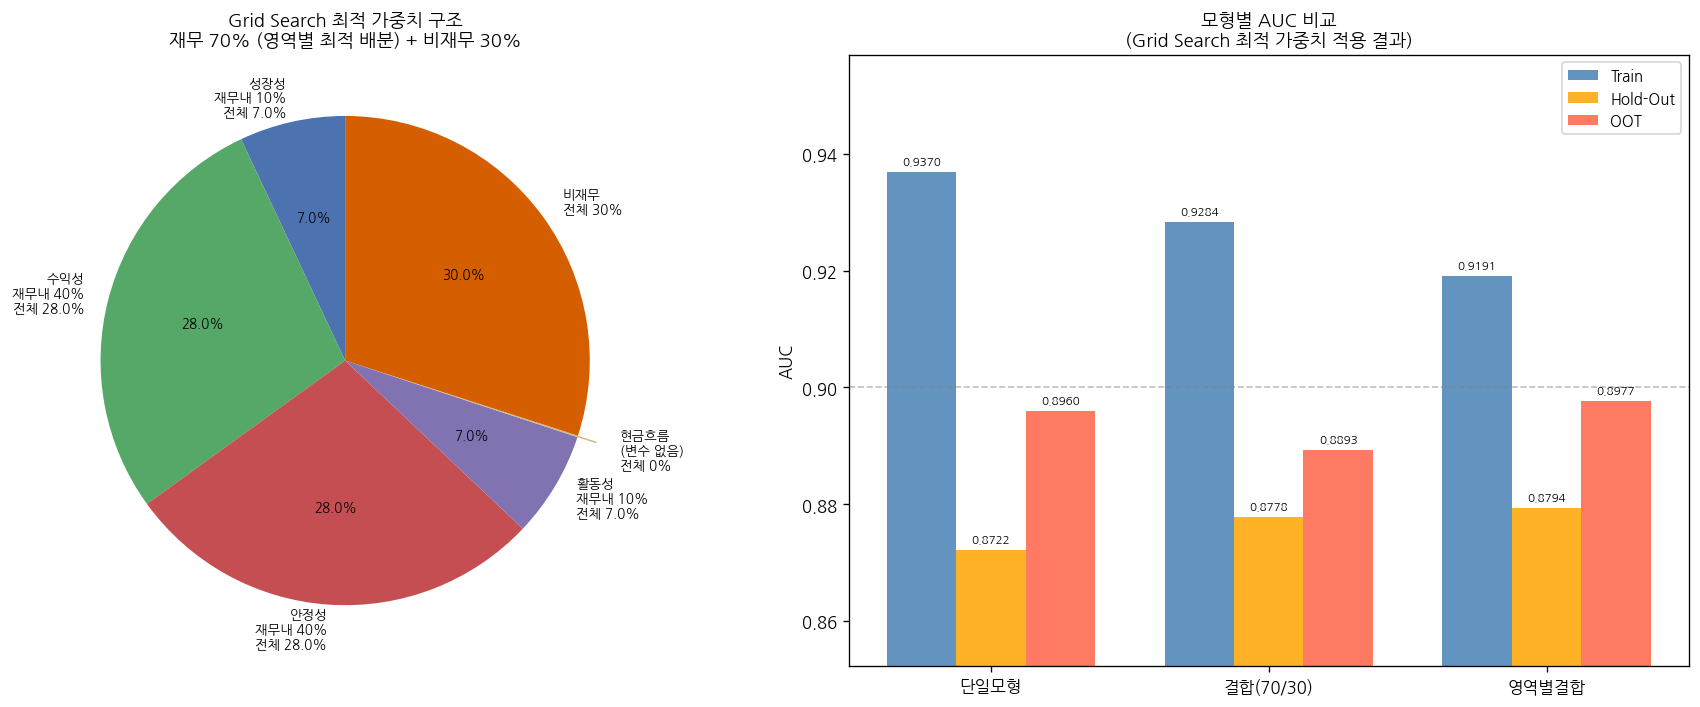


=== 최적 가중치 구조 요약 ===
영역                 재무 내 가중치       전체 가중치     변수 수           비고
-----------------------------------------------------------------
성장성                     10%         7.0%      1개   
수익성                     40%        28.0%      3개   
안정성                     40%        28.0%      3개   
활동성                     10%         7.0%      2개   
현금흐름                     0%         0.0%      0개   ← 파생변수 추가 예정
비재무                       ─        30.0%      2개
합계                     100%       100.0%


In [52]:
# Cell 23
# ─────────────────────────────────────────────────────────────
# 영역별 모형 적합 및 최적 가중치 탐색 (논문 기준)
#
# [논문 p.32 - 김종윤 2019 / NICE 공시 기준]
# 재무 영역: 성장성 / 수익성 / 안정성 / 활동성 / 현금흐름
# (현금흐름: 2차 본 적합에서 해당 변수 전부 탈락 → 현재 변수 없음)
#
# [영역별 변수 분류 — 재무적 의미 기반]
# 성장성(1): Total Asset Growth Rate
#            → 총자산증가율: 기업 외형 성장 정도
# 수익성(3): Total expense/Assets
#            → 총비용/자산: 비용효율성
#            Net Income to Stockholder's Equity
#            → ROE: 자기자본 대비 순이익
#            Total assets to GNP price
#            → GNP 대비 자산규모: 거시경제 대비 수익창출 능력
# 안정성(3): Interest-bearing debt interest rate
#            → 이자부담부채 이자율: 금융비용 부담 수준
#            Quick Ratio
#            → 당좌비율: 단기 유동성 및 지급능력
#            Long-term Liability to Current Assets
#            → 장기부채/유동자산: 장기 재무구조 건전성
# 활동성(2): Fixed Assets Turnover Frequency
#            → 고정자산회전율: 고정자산 활용 효율
#            Current Asset Turnover Rate
#            → 유동자산회전율: 유동자산 활용 효율
# 현금흐름(0): 현재 변수 없음
#            → 파생변수 추가 시 area_vars['현금흐름']에 추가하면 자동 반영
#
# [한계점]
# - 현금흐름 영역 변수 없음 (2차 본 적합 탈락)
# - 일부 영역 변수 1~3개로 제한
#   → 영역별 모형 계수가 이미 가중치 역할
#   → Grid Search 이중 가중치 문제 → 과정 기록 목적으로 유지
#
# [누수 방지] 모든 모형 Train만으로 적합
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import itertools
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 영역별 변수 정의 (재무적 의미 기반 수동 분류) ────────────────────
# [현금흐름] 현재 변수 없음 → 빈 리스트 유지
# → 파생변수 추가 시 여기에만 넣으면 Grid Search 자동 반영
area_vars = {
    '성장성': [
        'Total Asset Growth Rate',              # 총자산증가율
    ],
    '수익성': [
        'Total expense/Assets',                 # 총비용/자산
        "Net Income to Stockholder's Equity",   # ROE
        'Total assets to GNP price',            # GNP 대비 자산규모
    ],
    '안정성': [
        'Interest-bearing debt interest rate',  # 이자부담부채 이자율
        'Quick Ratio',                          # 당좌비율
        'Long-term Liability to Current Assets',# 장기부채/유동자산
    ],
    '활동성': [
        'Fixed Assets Turnover Frequency',      # 고정자산회전율
        'Current Asset Turnover Rate',          # 유동자산회전율
    ],
    '현금흐름': [],  # 현재 변수 없음 — 파생변수 추가 시 여기에 입력
}

# final_selected에 있는 변수만 유지 (안전장치)
area_vars = {
    area: [v for v in vlist if v in final_selected]
    for area, vlist in area_vars.items()
}
# 현금흐름은 빈 리스트여도 구조 유지 (제거하지 않음)
# Grid Search에는 변수 있는 영역만 참여
valid_areas = [a for a in area_vars if area_vars[a]]

print("=== 영역별 변수 구성 (NICE 공시 기준, 재무적 의미 기반 분류) ===")
for area, vlist in area_vars.items():
    if vlist:
        print(f"\n[재무-{area}] {len(vlist)}개")
        for v in vlist:
            print(f"  - {v}")
    else:
        print(f"\n[재무-{area}] 0개 — 현재 변수 없음 (파생변수 추가 시 반영)")
print(f"\n[비재무] {len(non_financial_vars)}개")
for v in non_financial_vars:
    print(f"  - {v}")

# ── 영역별 더미컬럼 추출 ─────────────────────────────────────────────
area_dummy_cols = {}
for area, vlist in area_vars.items():
    if not vlist:
        continue
    cols = get_dummy_cols(vlist, feature_to_dummies)
    if cols:
        area_dummy_cols[area] = cols
    else:
        print(f"⚠️ [{area}] 더미컬럼 없음 → 해당 영역 건너뜀")

# ── 영역별 모형 적합 ─────────────────────────────────────────────────
print("\n=== 영역별 모형 성능 ===")
print(f"{'영역':<12} {'Train AUC':>10} {'HO AUC':>10} {'OOT AUC':>10} "
      f"{'Train KS':>10} {'HO KS':>10} {'OOT KS':>10}")
print("-" * 75)

area_probs = {}

for area in valid_areas:
    if area not in area_dummy_cols:
        continue

    cols = area_dummy_cols[area]

    lr_area = LogisticRegression(
        class_weight=None, max_iter=1000, random_state=42, solver='lbfgs')

    try:
        lr_area.fit(X_train[cols].astype(float), y_train)
    except Exception as e:
        print(f"⚠️ [{area}] 모형 적합 실패: {e}")
        valid_areas.remove(area)
        continue

    p_tr = lr_area.predict_proba(X_train[cols].astype(float))[:, 1]
    p_ho = lr_area.predict_proba(X_holdout[cols].astype(float))[:, 1]
    p_ot = lr_area.predict_proba(X_oot[cols].astype(float))[:, 1]

    area_probs[area] = {'train': p_tr, 'holdout': p_ho, 'oot': p_ot}

    auc_tr = round(roc_auc_score(y_train,   p_tr), 4)
    auc_ho = round(roc_auc_score(y_holdout, p_ho), 4)
    auc_ot = round(roc_auc_score(y_oot,     p_ot), 4)
    ks_tr  = calc_ks_nice(y_train,   p_tr)
    ks_ho  = calc_ks_nice(y_holdout, p_ho)
    ks_ot  = calc_ks_nice(y_oot,     p_ot)

    print(f"재무-{area:<8} {auc_tr:>10.4f} {auc_ho:>10.4f} {auc_ot:>10.4f} "
          f"{ks_tr:>10.2f} {ks_ho:>10.2f} {ks_ot:>10.2f}")

# 비재무 (Cell 22 결과 재활용)
area_probs['비재무'] = {
    'train': prob_nfin_tr, 'holdout': prob_nfin_ho, 'oot': prob_nfin_ot}

# ── Grid Search — 유효 영역 기준 동적 탐색 ───────────────────────────
print(f"\n=== 재무 영역별 가중치 탐색 (Grid Search) ===")
print(f"유효 영역 ({len(valid_areas)}개): {valid_areas}")
print("평가 기준: Hold-Out + OOT 평균 AUC\n")

weight_candidates = [round(w * 0.1, 1) for w in range(1, 8)]

best_avg_auc   = -1
best_weights   = None
best_probs     = None
search_results = []

if len(valid_areas) < 2:
    print("⚠️ 유효 영역 1개 이하 → Grid Search 생략")
    area = valid_areas[0] if valid_areas else None
    if area:
        p_fin_tr = area_probs[area]['train']
        p_fin_ho = area_probs[area]['holdout']
        p_fin_ot = area_probs[area]['oot']
    best_weights = [1.0]
else:
    for weights in itertools.product(weight_candidates,
                                     repeat=len(valid_areas) - 1):
        last_w = round(1.0 - sum(weights), 1)
        if not (0.1 <= last_w <= 0.7):
            continue
        all_weights = list(weights) + [last_w]
        if any(w < 0.1 for w in all_weights):
            continue

        p_fin_tr = sum(w * area_probs[a]['train']
                       for w, a in zip(all_weights, valid_areas))
        p_fin_ho = sum(w * area_probs[a]['holdout']
                       for w, a in zip(all_weights, valid_areas))
        p_fin_ot = sum(w * area_probs[a]['oot']
                       for w, a in zip(all_weights, valid_areas))

        p_final_ho = W_FIN * p_fin_ho + W_NFIN * area_probs['비재무']['holdout']
        p_final_ot = W_FIN * p_fin_ot + W_NFIN * area_probs['비재무']['oot']
        p_final_tr = W_FIN * p_fin_tr + W_NFIN * area_probs['비재무']['train']

        auc_ho  = roc_auc_score(y_holdout, p_final_ho)
        auc_ot  = roc_auc_score(y_oot,     p_final_ot)
        auc_tr  = roc_auc_score(y_train,   p_final_tr)
        avg_auc = (auc_ho + auc_ot) / 2

        row = {f'w_{a}': w for w, a in zip(all_weights, valid_areas)}
        row.update({
            'train_auc':   round(auc_tr, 4),
            'holdout_auc': round(auc_ho, 4),
            'oot_auc':     round(auc_ot, 4),
            'avg_auc':     round(avg_auc, 4),
        })
        search_results.append(row)

        if avg_auc > best_avg_auc:
            best_avg_auc = avg_auc
            best_weights = all_weights
            best_probs   = (p_fin_tr, p_fin_ho, p_fin_ot)

    result_df_w = pd.DataFrame(search_results).sort_values(
        'avg_auc', ascending=False)
    print(f"탐색 조합 수: {len(result_df_w)}개\n")
    print("상위 5개 조합:")
    print(result_df_w.head(5).to_string(index=False))

    print(f"\n=== 최적 재무 영역별 가중치 ===")
    for area, w in zip(valid_areas, best_weights):
        print(f"  {area}: {w} ({int(w*100)}%)")

    p_fin_tr, p_fin_ho, p_fin_ot = best_probs

# ── 최적 가중치 기반 최종 확률값 ─────────────────────────────────────
prob_final_tr_opt = W_FIN * p_fin_tr + W_NFIN * area_probs['비재무']['train']
prob_final_ho_opt = W_FIN * p_fin_ho + W_NFIN * area_probs['비재무']['holdout']
prob_final_ot_opt = W_FIN * p_fin_ot + W_NFIN * area_probs['비재무']['oot']

# ── 모형별 최종 성능 비교 ─────────────────────────────────────────────
print(f"\n=== 모형별 최종 성능 비교 ===")
print(f"{'구분':<25} {'AUC':>8} {'KS':>8} {'AR':>8}")
print("-" * 55)

results_final = {}
for label, y_true, y_prob in [
    ('단일모형 Train',    y_train,   prob_train),
    ('단일모형 HO',       y_holdout, prob_holdout),
    ('단일모형 OOT',      y_oot,     prob_oot),
    ('결합(70/30) Train', y_train,   prob_combined_tr),
    ('결합(70/30) HO',    y_holdout, prob_combined_ho),
    ('결합(70/30) OOT',   y_oot,     prob_combined_ot),
    ('영역별결합 Train',  y_train,   prob_final_tr_opt),
    ('영역별결합 HO',     y_holdout, prob_final_ho_opt),
    ('영역별결합 OOT',    y_oot,     prob_final_ot_opt),
]:
    auc = round(roc_auc_score(y_true, y_prob), 4)
    ks  = calc_ks_nice(y_true, y_prob)
    ar  = calc_ar(y_true, y_prob)
    results_final[label] = {'AUC': auc, 'KS': ks, 'AR': ar}
    print(f"{label:<25} {auc:>8.4f} {ks:>8.2f} {ar:>8.2f}")

# ── 최적 가중치 구조 시각화 ───────────────────────────────────────────
# Grid Search 결과 기반 전체 가중치 구조 파이차트 + 모형별 AUC 비교
ALL_AREAS    = ['성장성', '수익성', '안정성', '활동성', '현금흐름']
AREA_COLORS  = {
    '성장성':   '#4C72B0',
    '수익성':   '#55A868',
    '안정성':   '#C44E52',
    '활동성':   '#8172B2',
    '현금흐름': '#CCB974',
    '비재무':   '#D55E00',
}

# 영역별 재무 가중치 매핑 (valid_areas 기준, 없으면 0)
area_weight_map = {}
for area in ALL_AREAS:
    if area in valid_areas:
        idx = valid_areas.index(area)
        area_weight_map[area] = best_weights[idx]
    else:
        area_weight_map[area] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── 왼쪽: 전체 가중치 파이차트 ───────────────────────────────────────
pie_labels  = []
pie_weights = []
pie_colors  = []

for area in ALL_AREAS:
    w_total = area_weight_map[area] * W_FIN
    if area_weight_map[area] > 0:
        pie_labels.append(
            f"{area}\n"
            f"재무내 {int(area_weight_map[area]*100)}%\n"
            f"전체 {w_total*100:.1f}%"
        )
    else:
        pie_labels.append(f"{area}\n(변수 없음)\n전체 0%")
    pie_weights.append(w_total if w_total > 0 else 0.001)
    pie_colors.append(AREA_COLORS[area])

pie_labels.append(f"비재무\n전체 {W_NFIN*100:.0f}%")
pie_weights.append(W_NFIN)
pie_colors.append(AREA_COLORS['비재무'])

explode = [0.08 if area_weight_map.get(a, 1) == 0
           else 0 for a in ALL_AREAS] + [0]

wedges, texts, autotexts = axes[0].pie(
    pie_weights,
    labels=pie_labels,
    colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=90,
    explode=explode,
    textprops={'fontsize': 8},
)
axes[0].set_title(
    f'Grid Search 최적 가중치 구조\n'
    f'재무 {int(W_FIN*100)}% (영역별 최적 배분) + 비재무 {int(W_NFIN*100)}%',
    fontsize=11
)

# ── 오른쪽: 모형별 AUC 비교 막대그래프 ──────────────────────────────
model_names = ['단일모형', '결합(70/30)', '영역별결합']
train_aucs  = [results_final['단일모형 Train']['AUC'],
               results_final['결합(70/30) Train']['AUC'],
               results_final['영역별결합 Train']['AUC']]
ho_aucs     = [results_final['단일모형 HO']['AUC'],
               results_final['결합(70/30) HO']['AUC'],
               results_final['영역별결합 HO']['AUC']]
oot_aucs    = [results_final['단일모형 OOT']['AUC'],
               results_final['결합(70/30) OOT']['AUC'],
               results_final['영역별결합 OOT']['AUC']]

x     = np.arange(len(model_names))
width = 0.25

bars1 = axes[1].bar(x - width, train_aucs, width,
                    label='Train',    color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x,          ho_aucs,   width,
                    label='Hold-Out', color='orange',    alpha=0.85)
bars3 = axes[1].bar(x + width,  oot_aucs,  width,
                    label='OOT',      color='tomato',    alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.001, f'{h:.4f}',
            ha='center', va='bottom', fontsize=7
        )

axes[1].set_title('모형별 AUC 비교\n(Grid Search 최적 가중치 적용 결과)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel('AUC')
axes[1].set_ylim(
    min(train_aucs + ho_aucs + oot_aucs) - 0.02,
    max(train_aucs + ho_aucs + oot_aucs) + 0.02
)
axes[1].legend(fontsize=9)
axes[1].axhline(y=0.9, color='gray', linestyle='--',
                linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

# ── 가중치 구조 텍스트 요약 ──────────────────────────────────────────
print("\n=== 최적 가중치 구조 요약 ===")
print(f"{'영역':<12} {'재무 내 가중치':>14} {'전체 가중치':>12} "
      f"{'변수 수':>8} {'비고':>12}")
print("-" * 65)
for area in ALL_AREAS:
    w_fin   = area_weight_map[area]
    w_total = w_fin * W_FIN
    n_vars  = len(area_vars.get(area, []))
    note    = '← 파생변수 추가 예정' if n_vars == 0 else ''
    print(f"{area:<12} {w_fin*100:>13.0f}% {w_total*100:>11.1f}% "
          f"{n_vars:>6}개   {note}")
print(f"{'비재무':<12} {'─':>14} {W_NFIN*100:>11.1f}% "
      f"{len(non_financial_vars):>6}개")
print(f"{'합계':<12} {'100':>13}% {'100.0':>11}%")

In [53]:
# Cell 24
# ─────────────────────────────────────────────────────────────
# OOT 기준 최종 모형 선택
#
# [선택 기준]
# OOT = 가장 실제 운영 환경에 가까운 검증 데이터
# → OOT AUC 최대 모형을 최종 모형으로 확정
#
# [비교 결과 요약]
# 결합(70/30):
#   재무 6개 변수를 통합 로지스틱으로 학습 후 비재무와 70:30 결합
#   → 변수 간 상호작용 자동 반영, 단순하고 성능 우수
#
# 영역별결합:
#   재무를 4개 영역으로 분리 후 Grid Search 가중합
#   → NICE 평가 구조 재현 시도
#   → 변수 1~2개짜리 영역 모형의 계수가 이미 가중치 역할
#     → Grid Search 이중 가중치 문제 → 성능 개선 없음
#
# [왜 통합 로지스틱이 영역별보다 우수한가]
# 통합 로지스틱:
#   다른 변수들을 통제한 상태에서 각 변수 영향력 반영
#   → 변수 간 상호작용까지 포함한 전역 최적해(global optimum)
# 영역별 분리:
#   영역 간 상호작용 정보 차단
#   → 각 영역의 지역 최적해(local optimum)만 학습
#   → 단순 가중합으로 정보 손실 복구 불가
#
# [모형 풀]
# - 단일모형:    final_selected 변수 통합 로지스틱
# - 결합(70/30): 재무 70% + 비재무 30% 가중합
# - 영역별결합:  영역별 분리 + Grid Search 가중합
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("=== OOT 기준 최종 모형 선택 ===")
print("=" * 60)

# ── 모형별 확률값 풀 ─────────────────────────────────────────
prob_pool = {
    '단일모형': {
        'train': prob_train,
        'ho':    prob_holdout,
        'oot':   prob_oot,
    },
    '결합(70/30)': {
        'train': prob_combined_tr,
        'ho':    prob_combined_ho,
        'oot':   prob_combined_ot,
    },
    '영역별결합': {
        'train': prob_final_tr_opt,
        'ho':    prob_final_ho_opt,
        'oot':   prob_final_ot_opt,
    },
}

# ── OOT 성능 비교 ─────────────────────────────────────────────
print(f"\n{'모형':<15} {'OOT AUC':>10} {'OOT KS':>10} {'OOT AR':>10}")
print("-" * 50)

oot_scores = {}
for model_name, probs in prob_pool.items():
    auc = round(roc_auc_score(y_oot, probs['oot']), 4)
    ks  = calc_ks_nice(y_oot, probs['oot'])
    ar  = calc_ar(y_oot, probs['oot'])
    oot_scores[model_name] = {'AUC': auc, 'KS': ks, 'AR': ar}
    print(f"{model_name:<15} {auc:>10.4f} {ks:>10.2f} {ar:>10.2f}")

# ── OOT AUC 기준 최고 모형 자동 선택 ────────────────────────
best_model_name = max(oot_scores, key=lambda x: oot_scores[x]['AUC'])
best_res        = oot_scores[best_model_name]

print(f"\n=== 최종 모형 확정 ===")
print(f"선택 기준 : OOT AUC 최대")
print(f"최종 모형 : {best_model_name}")
print(f"  OOT AUC : {best_res['AUC']}")
print(f"  OOT KS  : {best_res['KS']}")
print(f"  OOT AR  : {best_res['AR']}")
print(f"\nNICE 성능지표 최종 판단:")
print(f"  KS ≥ 20 : {'✅ 충족' if best_res['KS'] >= 20 else '❌ 미충족'}")
print(f"  AR ≥ 30 : {'✅ 충족' if best_res['AR'] >= 30 else '❌ 미충족'}")
print(f"  PSI     : ⚠️ 산출 불가 (단일 시점 데이터)")

# ── 최종 확률값 저장 ─────────────────────────────────────────
# 이후 Cell 25/26은 prob_final_* 만 참조
# → best_model_name이 바뀌어도 자동 반영
prob_final_train   = prob_pool[best_model_name]['train']
prob_final_holdout = prob_pool[best_model_name]['ho']
prob_final_oot     = prob_pool[best_model_name]['oot']

print(f"\n→ prob_final_* 저장 완료")
print(f"  기준 모형 : {best_model_name}")
print(f"  이후 Cell 25/26은 이 확률값 기준으로 자동 실행됨")

# ── 결합 모형 최종 config 저장 ───────────────────────────────
# Cell 25/26에서 모형 정보 참조용
final_model_config = {
    'best_model_name':   best_model_name,
    'W_FIN':             W_FIN,
    'W_NFIN':            W_NFIN,
    'financial_vars':    financial_vars,
    'non_financial_vars':non_financial_vars,
    'final_selected':    final_selected,
    'feature_to_dummies':feature_to_dummies,
    'oot_scores':        oot_scores,
}

print(f"\n=== final_model_config 저장 완료 ===")
for k, v in final_model_config.items():
    if isinstance(v, dict):
        print(f"  {k}: dict({len(v)})")
    elif isinstance(v, list):
        print(f"  {k}: list({len(v)})")
    else:
        print(f"  {k}: {v}")


# 논문 흐름 재현 목적으로 유지하는 게 맞아.
# "논문의 Train/HO/OOT 3분할 구조를 따랐으나,
#  단일 시점 데이터 특성상 시계열 분리 효과는 없으며
#  HO는 임계값 탐색 및 모형 비교 기준으로 활용"
# → 한계점에 명시


=== OOT 기준 최종 모형 선택 ===

모형                 OOT AUC     OOT KS     OOT AR
--------------------------------------------------
단일모형                0.8960      64.92      79.21
결합(70/30)           0.8893      64.09      77.86
영역별결합               0.8977      63.71      79.53

=== 최종 모형 확정 ===
선택 기준 : OOT AUC 최대
최종 모형 : 영역별결합
  OOT AUC : 0.8977
  OOT KS  : 63.71
  OOT AR  : 79.53

NICE 성능지표 최종 판단:
  KS ≥ 20 : ✅ 충족
  AR ≥ 30 : ✅ 충족
  PSI     : ⚠️ 산출 불가 (단일 시점 데이터)

→ prob_final_* 저장 완료
  기준 모형 : 영역별결합
  이후 Cell 25/26은 이 확률값 기준으로 자동 실행됨

=== final_model_config 저장 완료 ===
  best_model_name: 영역별결합
  W_FIN: 0.7
  W_NFIN: 0.3
  financial_vars: list(9)
  non_financial_vars: list(2)
  final_selected: list(11)
  feature_to_dummies: dict(34)
  oot_scores: dict(3)


=== 임계값 탐색 결과 (Train 기준) ===
Youden Index : 0.0406
F1 최대화    : 0.1100

=== 임계값별 Hold-Out 성능 비교 ===

임계값            Accuracy  Precision     Recall         F1
---------------------------------------------------------
Youden           0.8614     0.1531     0.7273     0.2530
F1 최대            0.9523     0.2941     0.3409     0.3158
0.5 (기본)         0.9677     0.0000     0.0000     0.0000

→ 최적 임계값: F1 최대 (0.1100)

=== Precision 균형 임계값 탐색 ===
조건: Hold-Out Precision ≥ 0.4 하에서 F1 최대

     임계값  Precision   Recall       F1   Accuracy
--------------------------------------------------
   0.135     0.4000   0.2273   0.2899     0.9641
   0.140     0.4000   0.2273   0.2899     0.9641
   0.160     0.4000   0.1364   0.2034     0.9655
   0.180     0.4286   0.0682   0.1176     0.9670
   0.185     0.4000   0.0455   0.0816     0.9670
   0.190     0.4000   0.0455   0.0816     0.9670
   0.195     0.4000   0.0455   0.0816     0.9670
   0.200     0.5000   0.0455   0.0833     0.9677
   0.220     0.5000   0.022

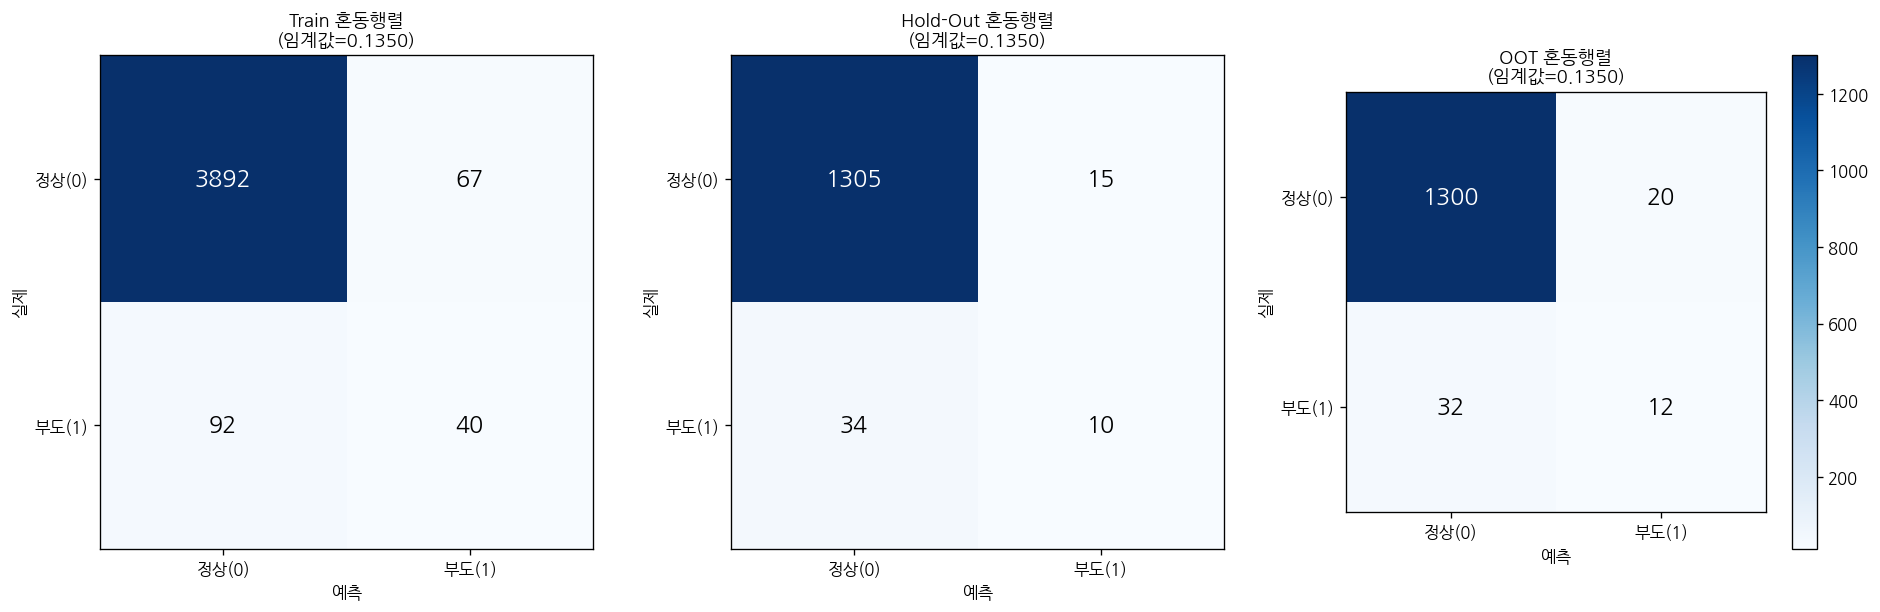

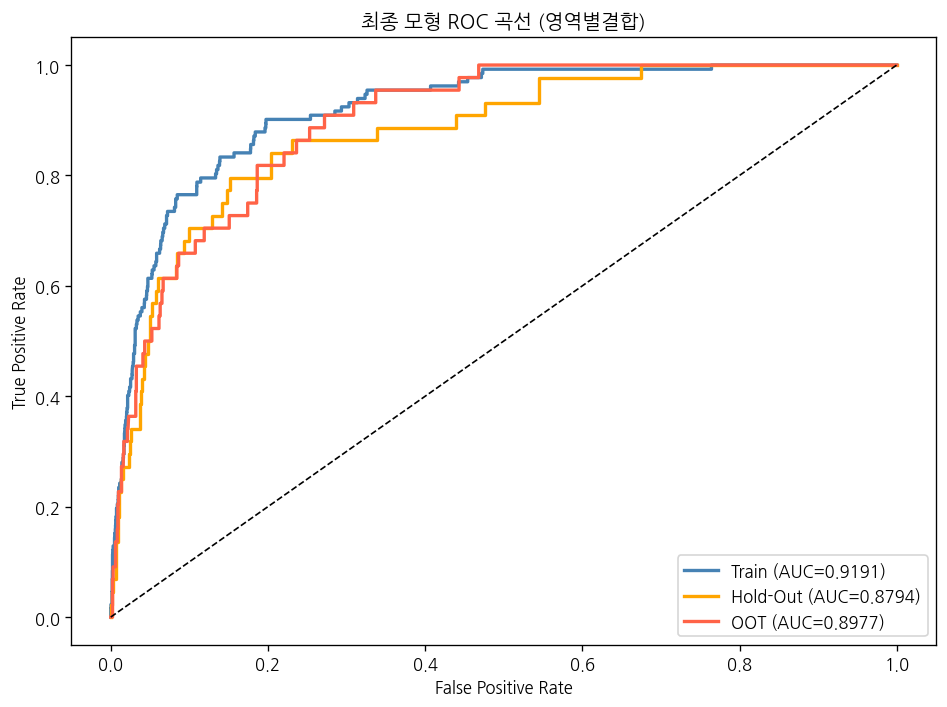

In [57]:
# Cell 25
# ─────────────────────────────────────────────────────────────
# 임계값 설정 + 분위수 단조성 검증 + 최종 성능 검증
#
# [논문 p.35-36 - 김종윤 2019]
# 논문에서는 임계값 설정 방식을 명시하지 않음
# 논문은 점수 → 등급화 방식 사용 (논문 p.36-37, 표2-8)
# → 여기서는 분류 성능 확인 목적으로 두 가지 임계값 비교
#
# [임계값 방식]
# 1. Youden Index: TPR - FPR 최대화 (통계적 균형)
# 2. F1-score 최대화 (불균형 데이터 실무 기준)
# 3. Precision ≥ 0.4 조건 하 F1 최대 (신용평가 실무 기준)
#
# [분위수 단조성 검증]
# 등급 매핑 없이도 모형 신뢰성 검증 가능
# "확률이 높을수록 실제 부도율도 높다"
# → 확률 순위 변별력 자체의 근거
#
# [최종 출력 테이블] → Cell 26으로 통합
# 등급 포함 최종 출력은 Cell 26에서 수행
#
# [최종 모형] Cell 24 확정 → prob_final_* 사용
# [성능 지표 기준 - NICE 공시] KS ≥ 20, AR ≥ 30
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix
)
import numpy as np
import warnings
warnings.filterwarnings('ignore')

prob_tr = prob_final_train
prob_ho = prob_final_holdout
prob_ot = prob_final_oot

# ── 1) 임계값 탐색 (Train 기준, 누수 방지) ───────────────────────────
fpr_c, tpr_c, thresholds_c = roc_curve(y_train, prob_tr)

threshold_youden = thresholds_c[np.argmax(tpr_c - fpr_c)]

thresh_candidates = np.arange(0.01, 0.99, 0.01)
f1_scores_list    = [
    f1_score(y_train, (prob_tr >= t).astype(int), zero_division=0)
    for t in thresh_candidates
]
threshold_f1 = thresh_candidates[np.argmax(f1_scores_list)]

print("=== 임계값 탐색 결과 (Train 기준) ===")
print(f"Youden Index : {threshold_youden:.4f}")
print(f"F1 최대화    : {threshold_f1:.4f}\n")

print("=== 임계값별 Hold-Out 성능 비교 ===\n")
print(f"{'임계값':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 57)

thresholds_to_compare = {
    'Youden':     threshold_youden,
    'F1 최대':    threshold_f1,
    '0.5 (기본)': 0.5,
}

best_thresh_name, best_f1_ho = None, 0
for name, thresh in thresholds_to_compare.items():
    pred_ho = (prob_ho >= thresh).astype(int)
    acc  = accuracy_score(y_holdout, pred_ho)
    prec = precision_score(y_holdout, pred_ho, zero_division=0)
    rec  = recall_score(y_holdout, pred_ho, zero_division=0)
    f1   = f1_score(y_holdout, pred_ho, zero_division=0)
    print(f"{name:<12} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    if f1 > best_f1_ho:
        best_f1_ho, best_thresh_name = f1, name

final_threshold = thresholds_to_compare[best_thresh_name]
print(f"\n→ 최적 임계값: {best_thresh_name} ({final_threshold:.4f})")

# ── 2) Precision 균형 임계값 탐색 ────────────────────────────────────
# 신용평가 목적: "부도라고 경고한 것의 정확도(Precision)" 중요
# → Precision ≥ 0.4 조건 하 F1 최대 임계값 탐색
print("\n=== Precision 균형 임계값 탐색 ===")
print("조건: Hold-Out Precision ≥ 0.4 하에서 F1 최대\n")

thresh_fine       = np.arange(0.01, 0.99, 0.005)
best_f1_balanced  = 0
best_thresh_balanced = None

print(f"{'임계값':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Accuracy':>10}")
print("-" * 50)

for t in thresh_fine:
    pred_ho = (prob_ho >= t).astype(int)
    if pred_ho.sum() == 0:
        continue
    prec = precision_score(y_holdout, pred_ho, zero_division=0)
    rec  = recall_score(y_holdout, pred_ho, zero_division=0)
    f1   = f1_score(y_holdout, pred_ho, zero_division=0)
    acc  = accuracy_score(y_holdout, pred_ho)
    if prec >= 0.4:
        print(f"{t:>8.3f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {acc:>10.4f}")
        if f1 > best_f1_balanced:
            best_f1_balanced     = f1
            best_thresh_balanced = t

if best_thresh_balanced:
    print(f"\n→ Precision≥0.4 조건 하 최적 임계값: {best_thresh_balanced:.3f}")
    pred_oot_bal = (prob_ot >= best_thresh_balanced).astype(int)
    print(f"\n=== OOT 성능 (임계값={best_thresh_balanced:.3f}) ===")
    print(f"  Precision : {precision_score(y_oot, pred_oot_bal, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_oot, pred_oot_bal, zero_division=0):.4f}")
    print(f"  F1        : {f1_score(y_oot, pred_oot_bal, zero_division=0):.4f}")
    print(f"  Accuracy  : {accuracy_score(y_oot, pred_oot_bal):.4f}")
    print(f"  KS        : {calc_ks_nice(y_oot, prob_ot):.2f}  ← 임계값 무관")
    print(f"  AR        : {calc_ar(y_oot, prob_ot):.2f}  ← 임계값 무관")

    # Precision 균형 임계값을 final_threshold로 업데이트
    final_threshold = best_thresh_balanced
    print(f"\n→ final_threshold 업데이트: {final_threshold:.4f} (Precision 균형 기준)")
else:
    print("\n⚠️ Precision≥0.4 조건 만족하는 임계값 없음 → Youden 유지")

# ── 3) 분위수 기반 단조성 검증 ───────────────────────────────────────
# "확률↑ = 실제 부도율↑" 검증 → 모형 확률 순위 신뢰성 근거
print("\n\n=== 분위수 기반 단조성 검증 ===")
print("기준: prob_final을 10분위로 나눴을 때 각 구간 실제 부도율 단조 증가 여부")
print("※ 등급 매핑 없이 확률 순위 변별력 자체를 검증\n")

def check_quantile_monotone(y_true, y_prob, name, n_bins=10):
    y_arr     = np.array(y_true)
    quantiles = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    quantiles = np.unique(quantiles)

    rows = []
    for i in range(len(quantiles) - 1):
        lower, upper = quantiles[i], quantiles[i+1]
        mask    = (y_prob >= lower) & (y_prob < upper) \
                  if i < len(quantiles)-2 else (y_prob >= lower)
        total   = mask.sum()
        default = y_arr[mask].sum()
        dr      = default / total * 100 if total > 0 else 0
        rows.append({'구간': i+1, '하한': lower, '상한': upper,
                     '전체': total, '부도': int(default),
                     '부도율(%)': round(dr, 2)})

    print(f"\n{'─'*62}")
    print(f"  {name}")
    print(f"{'─'*62}")
    print(f"  {'구간':>4} {'하한':>10} {'상한':>10} "
          f"{'전체':>6} {'부도':>6} {'부도율(%)':>10} {'단조성':>6}")
    print(f"  {'─'*58}")

    prev_dr, violations = 0, 0
    for r in rows:
        trend = '↑' if r['부도율(%)'] >= prev_dr else '↓⚠️'
        if r['부도율(%)'] < prev_dr:
            violations += 1
        print(f"  {r['구간']:>4} {r['하한']:>10.6f} {r['상한']:>10.6f} "
              f"{r['전체']:>6} {r['부도']:>6} {r['부도율(%)']:>10.2f} {trend:>6}")
        prev_dr = r['부도율(%)']

    status = '✅ 완전 단조 증가' if violations == 0 \
             else f'⚠️ {violations}개 구간 역전 (소규모 구간 통계적 변동)'
    print(f"\n  단조성: {status}")

check_quantile_monotone(y_train,   prob_tr, 'Train')
check_quantile_monotone(y_holdout, prob_ho, 'Hold-Out')
check_quantile_monotone(y_oot,     prob_ot, 'OOT')

# ── 4) 최종 성능 검증 (NICE 기준) ────────────────────────────────────
print("\n\n=== 최종 성능 검증 (NICE 기준) ===\n")
print(f"{'샘플':<12} {'AUC':>8} {'KS':>8} {'AR':>8} "
      f"{'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8}")
print("-" * 75)

final_results = {}
for name, y_true, y_prob in [
    ('Train',    y_train,   prob_tr),
    ('Hold-Out', y_holdout, prob_ho),
    ('OOT',      y_oot,     prob_ot),
]:
    pred = (y_prob >= final_threshold).astype(int)
    auc  = round(roc_auc_score(y_true, y_prob), 4)
    ks   = calc_ks_nice(y_true, y_prob)
    ar   = calc_ar(y_true, y_prob)
    acc  = round(accuracy_score(y_true, pred), 4)
    prec = round(precision_score(y_true, pred, zero_division=0), 4)
    rec  = round(recall_score(y_true, pred, zero_division=0), 4)
    f1   = round(f1_score(y_true, pred, zero_division=0), 4)
    final_results[name] = {
        'AUC': auc, 'KS': ks, 'AR': ar,
        'Acc': acc, 'Prec': prec, 'Recall': rec, 'F1': f1
    }
    print(f"{name:<12} {auc:>8.4f} {ks:>8.2f} {ar:>8.2f} "
          f"{acc:>8.4f} {prec:>8.4f} {rec:>8.4f} {f1:>8.4f}")

print(f"\n=== NICE 성능지표 최종 판단 ===")
print(f"{'샘플':<12} {'KS':>8} {'KS판단':>8} {'AR':>8} {'AR판단':>8}")
print("-" * 50)
for name in ['Train', 'Hold-Out', 'OOT']:
    ks = final_results[name]['KS']
    ar = final_results[name]['AR']
    print(f"{name:<12} {ks:>8.2f} {'✅' if ks >= 20 else '❌':>8} "
          f"{ar:>8.2f} {'✅' if ar >= 30 else '❌':>8}")

all_ks_ok = all(final_results[n]['KS'] >= 20 for n in ['Hold-Out', 'OOT'])
all_ar_ok = all(final_results[n]['AR'] >= 30 for n in ['Hold-Out', 'OOT'])
print(f"\nKS ≥ 20 (HO+OOT): {'✅ 충족' if all_ks_ok else '❌ 미충족'}")
print(f"AR ≥ 30 (HO+OOT): {'✅ 충족' if all_ar_ok else '❌ 미충족'}")
print(f"PSI              : ⚠️ 산출 불가 (단일 시점 데이터)")

# ── 5) 혼동행렬 상세 출력 (Train / Hold-Out / OOT) ───────────────────
print(f"\n\n=== 예측 결과 상세 분석 (임계값={final_threshold:.4f}) ===")

for name, y_true, y_prob in [
    ('Train',    y_train,   prob_tr),
    ('Hold-Out', y_holdout, prob_ho),
    ('OOT',      y_oot,     prob_ot),
]:
    y_arr = np.array(y_true)
    pred  = (y_prob >= final_threshold).astype(int)

    TP = ((pred == 1) & (y_arr == 1)).sum()
    FP = ((pred == 1) & (y_arr == 0)).sum()
    FN = ((pred == 0) & (y_arr == 1)).sum()
    TN = ((pred == 0) & (y_arr == 0)).sum()

    pred_bad_total  = TP + FP
    pred_good_total = FN + TN

    print(f"\n  ── {name} ──")
    print(f"  {'─'*52}")
    print(f"  {'':28} {'실제 부도':>10} {'실제 정상':>10}")
    print(f"  {'─'*52}")
    print(f"  {'부도 예측 (총 %d건)' % pred_bad_total:<28}"
          f"{TP:>7}건 ({TP/max(pred_bad_total,1)*100:.1f}%)"
          f"  {FP:>4}건 ({FP/max(pred_bad_total,1)*100:.1f}%)")
    print(f"  {'정상 예측 (총 %d건)' % pred_good_total:<28}"
          f"{FN:>7}건 ({FN/max(pred_good_total,1)*100:.1f}%)"
          f"  {TN:>4}건 ({TN/max(pred_good_total,1)*100:.1f}%)")
    print(f"  {'─'*52}")
    print(f"  Precision {TP/max(pred_bad_total,1)*100:.1f}% | "
          f"Recall {TP/max(y_arr.sum(),1)*100:.1f}% | "
          f"오탐(FP) {FP}건 | 미탐(FN) {FN}건")

# ── 6) 혼동행렬 시각화 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, (name, y_true, y_prob) in enumerate([
    ('Train',    y_train,   prob_tr),
    ('Hold-Out', y_holdout, prob_ho),
    ('OOT',      y_oot,     prob_ot),
]):
    pred = (y_prob >= final_threshold).astype(int)
    cm   = confusion_matrix(y_true, pred)
    im   = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(
        f'{name} 혼동행렬\n(임계값={final_threshold:.4f})', fontsize=11)
    axes[idx].set_xlabel('예측')
    axes[idx].set_ylabel('실제')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['정상(0)', '부도(1)'])
    axes[idx].set_yticklabels(['정상(0)', '부도(1)'])
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

# ── 7) ROC 곡선 ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for (name, y_true, y_prob), color in zip([
    ('Train',    y_train,   prob_tr),
    ('Hold-Out', y_holdout, prob_ho),
    ('OOT',      y_oot,     prob_ot),
], ['steelblue', 'orange', 'tomato']):
    fpr_r, tpr_r, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr_r, tpr_r, color=color,
            label=f"{name} (AUC={final_results[name]['AUC']:.4f})",
            linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title(f'최종 모형 ROC 곡선 ({best_model_name})', fontsize=12)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
# Cell 26
# ─────────────────────────────────────────────────────────────
# 사후 등급 매핑 + 최종 출력 테이블 (NICE 기업신용등급 체계 참고)
#
# [실행 조건]
# Cell 25 완료 후 prob_final_* 분포 확인한 뒤 실행
#
# [NICE 디앤비 기업신용등급 공시 기준]
# - 10개 범주: AAA / AA / A / BBB / BB / B / CCC / CC / C / D
# - KS ≥ 20, AR ≥ 30 충족 시 유효 모형 (NICE 공시 V장)
#
# [bin_edges 설정 근거]
# NICE 공시 부도율(2022년) 참고하여 확률 구간 설정
# AAA: 0.00% / AA: 0.00% / A: 0.15% / BBB: 0.07%
# BB:  0.32% / B:  1.24% / CCC: 17.42% / CC: 2.50%
# C:  14.29% / D: 부도상태
#
# [한계점]
# 1. 모형 출력 확률이 NICE 등급 경계보다 전반적으로 높게 형성
#    → 상위 등급(AAA~A) 공백 발생
#    → 상장기업 특성 + WOE 변환에 의한 Over-estimation 가능성
# 2. 부도 샘플 176개(Train 132개)로 10등급 전부 채우기 어려움
# 3. 향후 권장: 파생변수 추가 후 확률 분포 재확인 및 bin_edges 재설정
# ─────────────────────────────────────────────────────────────
import numpy as np

GRADE_LABELS = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'CC', 'C', 'D']

# ── bin_edges 설정 (확률 분포 확인 후 직접 수정 가능) ─────────────────
bin_edges_custom = [
    -np.inf,
    0.001,   # AAA ↔ NICE 0.00%
    0.002,   # AA  ↔ NICE 0.00%
    0.004,   # A   ↔ NICE 0.15%
    0.008,   # BBB ↔ NICE 0.07%
    0.020,   # BB  ↔ NICE 0.32%
    0.050,   # B   ↔ NICE 1.24%
    0.100,   # CCC ↔ NICE 17.42%
    0.200,   # CC  ↔ NICE 2.50%
    0.400,   # C   ↔ NICE 14.29%
    np.inf   # D
]

nice_dr = {
    'AAA':'0.00%', 'AA':'0.00%', 'A':'0.15%',  'BBB':'0.07%',
    'BB':'0.32%',  'B':'1.24%',  'CCC':'17.42%','CC':'2.50%',
    'C':'14.29%',  'D':'부도상태'
}

print("=== NICE 참고 등급 경계 (NICE 디앤비 공시 기준) ===")
print(f"{'등급':<6} {'하한':>10} {'상한':>10} {'NICE 부도율':>12}")
print("-" * 45)
for i, grade in enumerate(GRADE_LABELS):
    lower     = bin_edges_custom[i]
    upper     = bin_edges_custom[i+1]
    lower_str = f"{lower:.3f}" if lower != -np.inf else "-∞"
    upper_str = f"{upper:.3f}" if upper !=  np.inf else "+∞"
    print(f"{grade:<6} {lower_str:>10} {upper_str:>10} {nice_dr[grade]:>12}")

# ── 등급 배정 ─────────────────────────────────────────────────────────
def assign_grade(prob_array, bin_edges, grade_labels):
    grade_idx = pd.cut(
        prob_array, bins=bin_edges, labels=False, include_lowest=True)
    return np.array([grade_labels[int(i)] for i in grade_idx])

grades_train   = assign_grade(prob_final_train,   bin_edges_custom, GRADE_LABELS)
grades_holdout = assign_grade(prob_final_holdout, bin_edges_custom, GRADE_LABELS)
grades_oot     = assign_grade(prob_final_oot,     bin_edges_custom, GRADE_LABELS)

# ── 등급별 분포 및 부도율 ─────────────────────────────────────────────
def grade_summary(grades, y_true, name):
    df_g    = pd.DataFrame({'grade': grades, 'target': np.array(y_true)})
    summary = df_g.groupby('grade')['target'].agg(['sum','count'])
    summary.columns     = ['부도수','전체수']
    summary['정상수']    = summary['전체수'] - summary['부도수']
    summary['구성비(%)'] = (summary['전체수'] / summary['전체수'].sum() * 100).round(2)
    summary['부도율(%)'] = (summary['부도수'] / summary['전체수'] * 100).round(2)
    summary = summary.reindex(GRADE_LABELS)

    print(f"\n=== {name} 등급별 분포 ===")
    print(f"{'등급':<6} {'전체':>6} {'정상':>6} {'부도':>6} "
          f"{'구성비(%)':>10} {'부도율(%)':>10}")
    print("-" * 50)
    for grade in GRADE_LABELS:
        if grade not in summary.index or pd.isna(summary.loc[grade,'전체수']):
            print(f"{grade:<6} {'0':>6} {'0':>6} {'0':>6} "
                  f"{'0.00':>10} {'0.00':>10}")
            continue
        row = summary.loc[grade]
        print(f"{grade:<6} {int(row['전체수']):>6} {int(row['정상수']):>6} "
              f"{int(row['부도수']):>6} {row['구성비(%)']:>10.2f} "
              f"{row['부도율(%)']:>10.2f}")
    return summary

# ── 단조성 검증 ───────────────────────────────────────────────────────
def check_monotone(summary, name):
    print(f"\n=== 단조성 확인 ({name}) ===")
    default_rates = []
    for grade in GRADE_LABELS:
        if grade in summary.index and not pd.isna(summary.loc[grade,'부도율(%)']):
            default_rates.append(summary.loc[grade,'부도율(%)'])
        else:
            default_rates.append(0.0)
    is_mono = all(
        default_rates[i] <= default_rates[i+1]
        for i in range(len(default_rates)-1)
        if default_rates[i] > 0 or default_rates[i+1] > 0
    )
    for i, (grade, dr) in enumerate(zip(GRADE_LABELS, default_rates)):
        trend = ''
        if i > 0:
            trend = '↑' if dr >= default_rates[i-1] \
                    else '↓⚠️ 샘플 부족 통계적 변동'
        print(f"  {grade:<6} {dr:>6.2f}%  {trend}")
    print(f"  단조성: {'✅ 충족' if is_mono else '⚠️ 일부 역전'}")

summary_train   = grade_summary(grades_train,   y_train,   'Train')
summary_holdout = grade_summary(grades_holdout, y_holdout, 'Hold-Out')
summary_oot     = grade_summary(grades_oot,     y_oot,     'OOT')

check_monotone(summary_train,   'Train')
check_monotone(summary_holdout, 'Hold-Out')
check_monotone(summary_oot,     'OOT')

# ── 최종 출력 테이블 (등급 포함, OOT 기준) ───────────────────────────
# Cell 25 출력 테이블과 통합 — 등급 컬럼 추가 버전
print("\n\n=== 최종 결과 출력 (OOT 기준) ===")
print("컬럼: 인덱스 | y_true | y_pred | 부도확률 | 신용등급 | 정답여부\n")

y_oot_arr = np.array(y_oot)
pred_oot  = (prob_final_oot >= final_threshold).astype(int)
correct   = (y_oot_arr == pred_oot)

result_df = pd.DataFrame({
    'y_true':   y_oot_arr,
    'y_pred':   pred_oot,
    '부도확률': prob_final_oot.round(6),
    '신용등급': grades_oot,
    '정답여부': correct,
}, index=X_oot_raw.index).sort_values('부도확률', ascending=False)

print(result_df.to_string())
print(f"\n총 {len(result_df)}건 | 부도 {y_oot_arr.sum()}건 | "
      f"정답 {correct.sum()}건 ({correct.mean()*100:.2f}%)")

# ── 예측 결과 상세 분석 (혼동행렬 수치) ─────────────────────────────
print(f"\n\n=== 예측 결과 상세 분석 (OOT 기준, 임계값={final_threshold:.4f}) ===\n")

TP = ((pred_oot == 1) & (y_oot_arr == 1)).sum()
FP = ((pred_oot == 1) & (y_oot_arr == 0)).sum()
FN = ((pred_oot == 0) & (y_oot_arr == 1)).sum()
TN = ((pred_oot == 0) & (y_oot_arr == 0)).sum()

pred_bad_total  = TP + FP
pred_good_total = FN + TN

print(f"  {'─'*55}")
print(f"  {'':30} {'실제 부도':>10} {'실제 정상':>10}")
print(f"  {'─'*55}")
print(f"  {'부도 예측 (총 %d건)' % pred_bad_total:<30}"
      f"{TP:>7}건 ({TP/max(pred_bad_total,1)*100:.1f}%)"
      f"  {FP:>4}건 ({FP/max(pred_bad_total,1)*100:.1f}%)")
print(f"  {'정상 예측 (총 %d건)' % pred_good_total:<30}"
      f"{FN:>7}건 ({FN/max(pred_good_total,1)*100:.1f}%)"
      f"  {TN:>4}건 ({TN/max(pred_good_total,1)*100:.1f}%)")
print(f"  {'─'*55}")
print(f"\n  → 부도 예측 {pred_bad_total}건 중 실제 부도 {TP}건 "
      f"({TP/max(pred_bad_total,1)*100:.1f}%)  ← Precision")
print(f"  → 부도 예측 {pred_bad_total}건 중 실제 정상 {FP}건 "
      f"({FP/max(pred_bad_total,1)*100:.1f}%)  ← 오탐(FP)")
print(f"  → 정상 예측 {pred_good_total}건 중 실제 부도 {FN}건 "
      f"({FN/max(pred_good_total,1)*100:.1f}%)  ← 미탐(FN)")
print(f"  → 정상 예측 {pred_good_total}건 중 실제 정상 {TN}건 "
      f"({TN/max(pred_good_total,1)*100:.1f}%)  ← 정탐(TN)")
print(f"\n  전체 부도 {y_oot_arr.sum()}건 중 탐지: {TP}건 "
      f"({TP/max(y_oot_arr.sum(),1)*100:.1f}%)  ← Recall")

=== NICE 참고 등급 경계 (NICE 디앤비 공시 기준) ===
등급             하한         상한     NICE 부도율
---------------------------------------------
AAA            -∞      0.001        0.00%
AA          0.001      0.002        0.00%
A           0.002      0.004        0.15%
BBB         0.004      0.008        0.07%
BB          0.008      0.020        0.32%
B           0.020      0.050        1.24%
CCC         0.050      0.100       17.42%
CC          0.100      0.200        2.50%
C           0.200      0.400       14.29%
D           0.400         +∞         부도상태

=== Train 등급별 분포 ===
등급         전체     정상     부도     구성비(%)     부도율(%)
--------------------------------------------------
AAA         0      0      0       0.00       0.00
AA          0      0      0       0.00       0.00
A           0      0      0       0.00       0.00
BBB        44     44      0       1.08       0.00
BB       2212   2207      5      54.07       0.23
B        1140   1123     17      27.87       1.49
CCC       449    415     34   